In [1]:
import init

In [2]:
epochs = 100

In [3]:
import tensorflow as tf


def get_dataset(x, y, batch_size=128, shuffle_buffer=10_000, drop_remainder=True):
    """Scale image bytes to diffusion space and batch aligned labels.

    The affine transform does not clip values. No prefetching, repetition, validation
    split, or deterministic shuffle seed is added. Labels remain aligned with images
    while shuffling.

    Args:
        x (np.ndarray): Image values nominally in [0, 255]. Expected NHW grayscale
            input; a singleton channel is appended unconditionally.
        y (np.ndarray): Labels with the same leading length as x. Values and label shape
            are preserved.
        batch_size (int): Number of examples in each dataset batch. Defaults to ``128``.
        shuffle_buffer (int | None): None preserves input order; a positive integer
            enables shuffling without an explicit operation seed. TensorFlow global
            seeding can still control this randomness. Defaults to ``10000``.
        drop_remainder (bool): True discards an incomplete final batch; False retains
            it. Defaults to ``True``.

    Returns:
        tf.data.Dataset: Finite (images, labels) batches, with float32 image values
        transformed as 2*x/255-1 and the configured remainder policy.
    """

    x = x.astype("float32") / 255.0
    x = (x * 2.0) - 1.0
    x = x[..., None]

    dataset = tf.data.Dataset.from_tensor_slices((x, y))
    # A supplied buffer enables random shuffling; None keeps input order.
    if shuffle_buffer is not None:
        dataset = dataset.shuffle(shuffle_buffer)
    dataset = dataset.batch(batch_size, drop_remainder=drop_remainder)

    return dataset

In [4]:
from tensorflow.keras import datasets


(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

trainset = get_dataset(x_train, y_train)
valset = get_dataset(x_test, y_test, shuffle_buffer=None, drop_remainder=False)

In [5]:
from diffusion.models.transformer.di_t_classifier import DiTClassifier
from diffusion.models.wrapper.diffusion_classifier_v2 import DiffusionClassifierV2


vit = DiTClassifier(
    patchify_with_cnn=True, 
    # time_freq_dim=256, 
    # time_mlp_ratio=1/8, 
    depth=3, 
    clf_depth=2
)
model = DiffusionClassifierV2(
    network=vit, 
    clf_train_noisified_max_timesteps=256
)

vit.summary()

Model: "di_t_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 depth_0_patch_embedder (Pat  (None, 196, 32)          4800      
 chEmbedding)                                                    
                                                                 
 depth_0_time_embedder (Cond  (None, 32)               32000     
 itionEmbedding)                                                 
                                                                 
 depth_0_label_embedder (Con  (None, 32)               352       
 ditionEmbedding)                                                
                                                                 
 depth_0_time_label_merger (  (None, 32)               0         
 Add)                                                            
                                                                 
 depth_1_encoder_block (Visi  (None, 196, 32)      

In [6]:
from tensorflow.keras import optimizers


lr_schedule = optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-3, 
    decay_steps=epochs * len(trainset)
)

model.compile(
    optimizer=optimizers.Adam(lr_schedule), 
    loss="mse", 
)

In [7]:
from tensorflow.keras import callbacks

from diffusion import ImageGenerator
from common.callbacks.lr_logger import LrLogger


callbacks_list = [
    LrLogger(), 
    callbacks.ProgbarLogger(count_mode="steps"), 
    ImageGenerator()
]

In [8]:
model.gen_vars_names

['depth_0_patch_embedder/patch_projector/conv_1/kernel:0',
 'depth_0_patch_embedder/patch_projector/conv_1/bias:0',
 'depth_0_patch_embedder/patch_projector/conv_2/kernel:0',
 'depth_0_patch_embedder/patch_projector/conv_2/bias:0',
 'depth_0_label_embedder/embeddings/embeddings:0',
 'depth_1_encoder_block/mha_layer_norm/mlp/final_layer/kernel:0',
 'depth_1_encoder_block/mha_layer_norm/mlp/final_layer/bias:0',
 'depth_1_encoder_block/mha/query/kernel:0',
 'depth_1_encoder_block/mha/query/bias:0',
 'depth_1_encoder_block/mha/key/kernel:0',
 'depth_1_encoder_block/mha/key/bias:0',
 'depth_1_encoder_block/mha/value/kernel:0',
 'depth_1_encoder_block/mha/value/bias:0',
 'depth_1_encoder_block/mha/attention_output/kernel:0',
 'depth_1_encoder_block/mha/attention_output/bias:0',
 'depth_1_encoder_block/mlp_layer_norm/mlp/final_layer/kernel:0',
 'depth_1_encoder_block/mlp_layer_norm/mlp/final_layer/bias:0',
 'depth_1_encoder_block/mlp/first_layer/kernel:0',
 'depth_1_encoder_block/mlp/first_la

In [9]:
model.clf_vars_names

['clf_depth_0_cls_token/token_embeddings:0',
 'clf_depth_0_cls_token/positional_embeddings:0',
 'clf_depth_1_encoder_block/mha_layer_norm/mlp/final_layer/kernel:0',
 'clf_depth_1_encoder_block/mha_layer_norm/mlp/final_layer/bias:0',
 'clf_depth_1_encoder_block/mha/query/kernel:0',
 'clf_depth_1_encoder_block/mha/query/bias:0',
 'clf_depth_1_encoder_block/mha/key/kernel:0',
 'clf_depth_1_encoder_block/mha/key/bias:0',
 'clf_depth_1_encoder_block/mha/value/kernel:0',
 'clf_depth_1_encoder_block/mha/value/bias:0',
 'clf_depth_1_encoder_block/mha/attention_output/kernel:0',
 'clf_depth_1_encoder_block/mha/attention_output/bias:0',
 'clf_depth_1_encoder_block/mlp_layer_norm/mlp/final_layer/kernel:0',
 'clf_depth_1_encoder_block/mlp_layer_norm/mlp/final_layer/bias:0',
 'clf_depth_1_encoder_block/mlp/first_layer/kernel:0',
 'clf_depth_1_encoder_block/mlp/first_layer/bias:0',
 'clf_depth_1_encoder_block/mlp/final_layer/kernel:0',
 'clf_depth_1_encoder_block/mlp/final_layer/bias:0',
 'clf_depth

Epoch 1/100
468/468 [==============================] - 40s 64ms/step - noise_loss: 0.0768 - val_loss: 0.6312 - val_noise_loss: 0.6312 - val_image_loss: 19.8110 - learning_rate: 0.0050


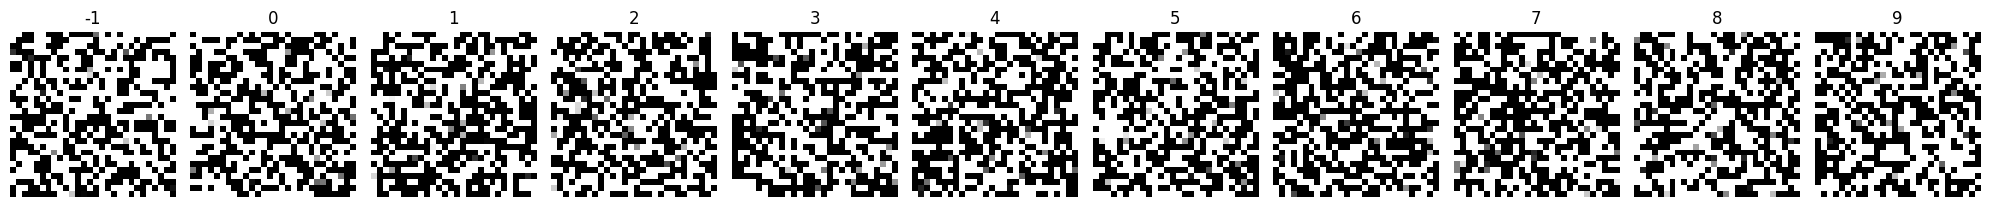

Epoch 2/100
468/468 [==============================] - 28s 60ms/step - noise_loss: 0.0420 - val_loss: 0.2771 - val_noise_loss: 0.2771 - val_image_loss: 7.4617 - learning_rate: 0.0050


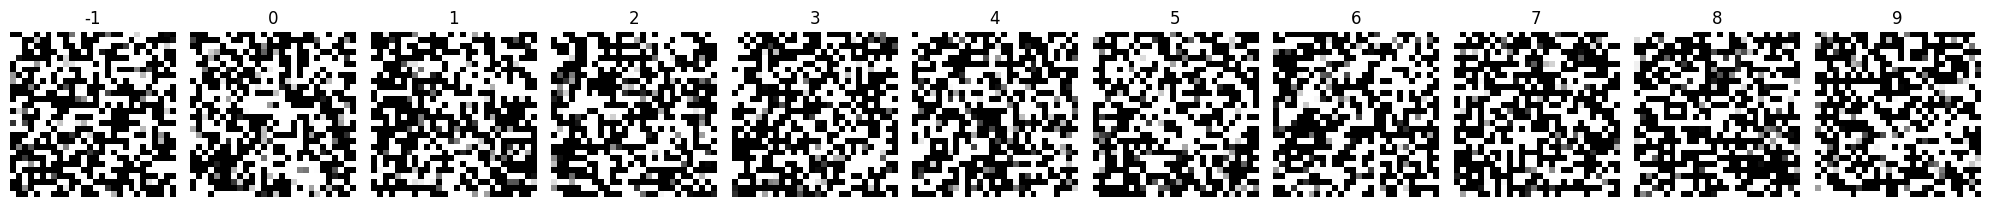

Epoch 3/100
468/468 [==============================] - 29s 62ms/step - noise_loss: 0.0394 - val_loss: 0.1519 - val_noise_loss: 0.1519 - val_image_loss: 3.3850 - learning_rate: 0.0050


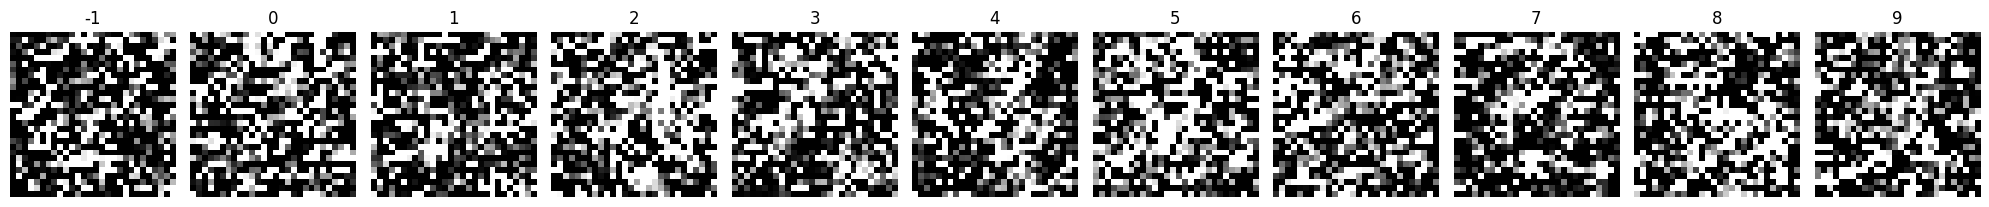

Epoch 4/100
468/468 [==============================] - 29s 61ms/step - noise_loss: 0.0373 - val_loss: 0.0904 - val_noise_loss: 0.0904 - val_image_loss: 1.5252 - learning_rate: 0.0050


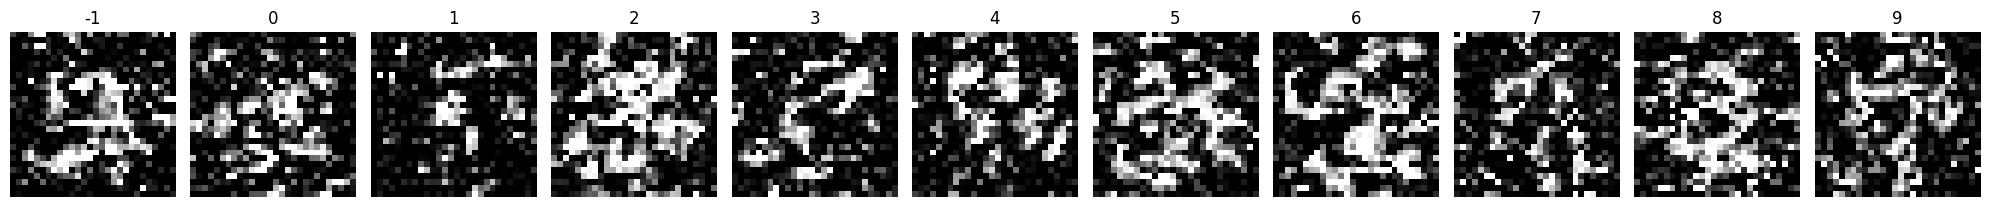

Epoch 5/100
468/468 [==============================] - 28s 59ms/step - noise_loss: 0.0360 - val_loss: 0.0610 - val_noise_loss: 0.0610 - val_image_loss: 0.7071 - learning_rate: 0.0050


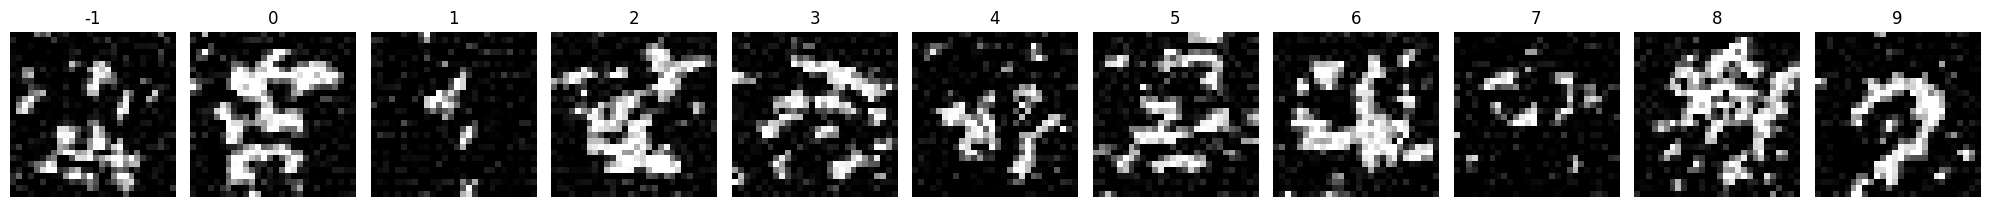

Epoch 6/100
468/468 [==============================] - 29s 62ms/step - noise_loss: 0.0351 - val_loss: 0.0472 - val_noise_loss: 0.0472 - val_image_loss: 0.4238 - learning_rate: 0.0050


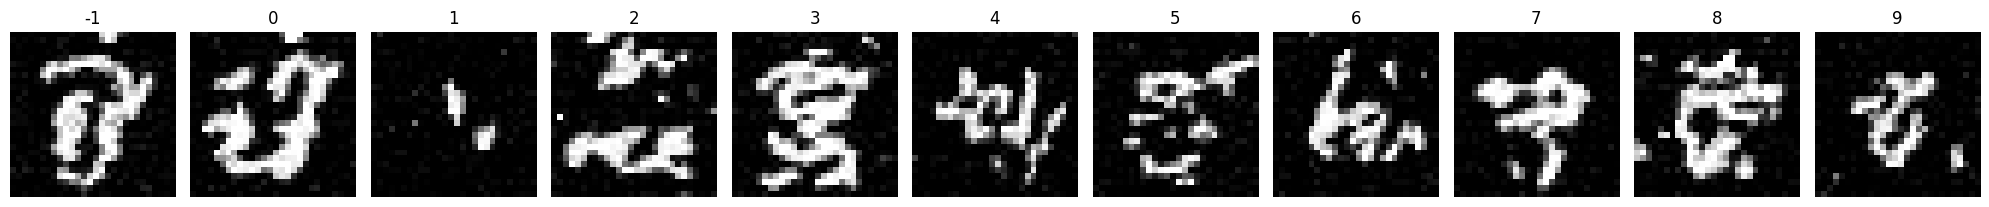

Epoch 7/100
468/468 [==============================] - 29s 62ms/step - noise_loss: 0.0339 - val_loss: 0.0426 - val_noise_loss: 0.0426 - val_image_loss: 0.2729 - learning_rate: 0.0049


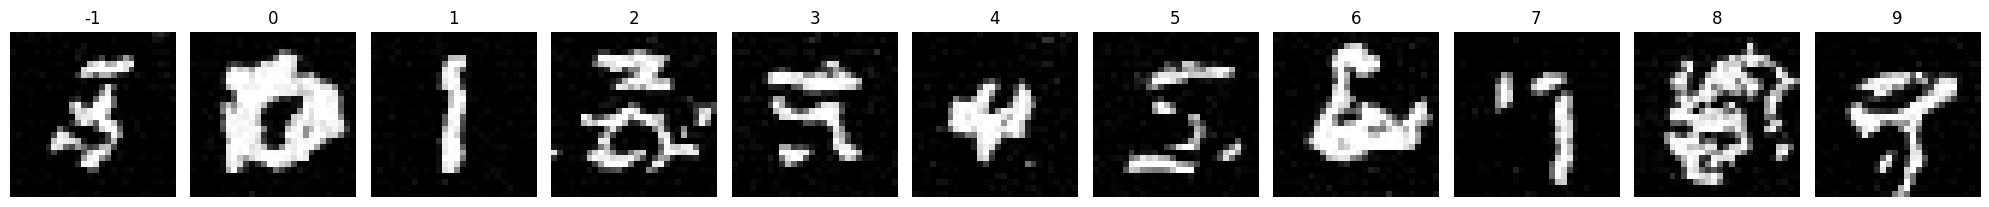

Epoch 8/100
468/468 [==============================] - 30s 63ms/step - noise_loss: 0.0331 - val_loss: 0.0415 - val_noise_loss: 0.0415 - val_image_loss: 0.2167 - learning_rate: 0.0049


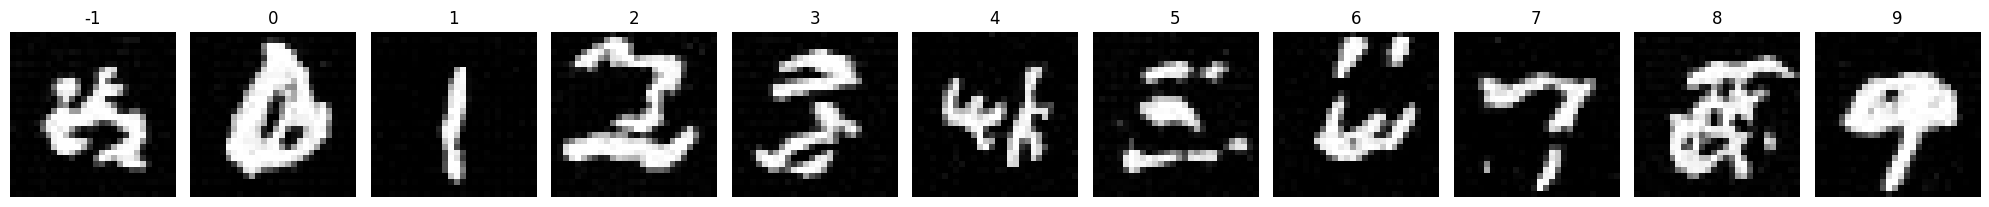

Epoch 9/100
468/468 [==============================] - 30s 63ms/step - noise_loss: 0.0325 - val_loss: 0.0413 - val_noise_loss: 0.0413 - val_image_loss: 0.1991 - learning_rate: 0.0049


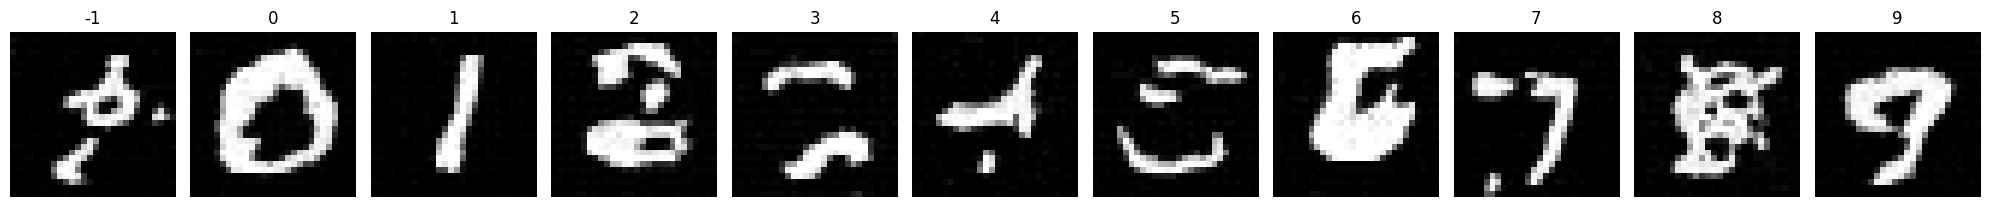

Epoch 10/100
468/468 [==============================] - 36s 77ms/step - noise_loss: 0.0319 - val_loss: 0.0433 - val_noise_loss: 0.0433 - val_image_loss: 0.1889 - learning_rate: 0.0049


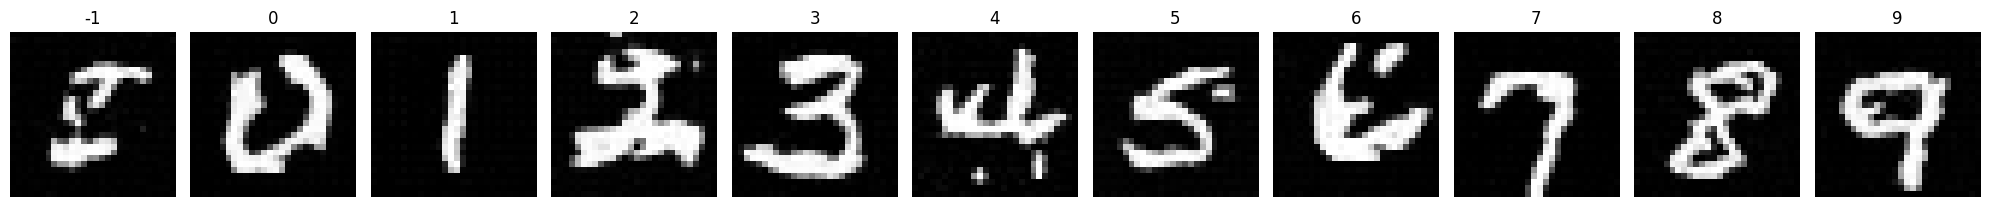

Epoch 11/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0316 - val_loss: 0.0442 - val_noise_loss: 0.0442 - val_image_loss: 0.2079 - learning_rate: 0.0049


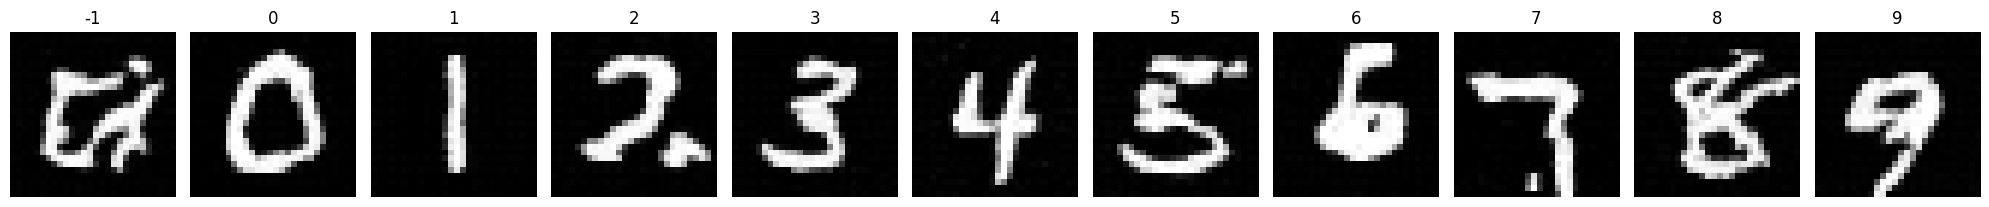

Epoch 12/100
468/468 [==============================] - 38s 80ms/step - noise_loss: 0.0312 - val_loss: 0.0461 - val_noise_loss: 0.0461 - val_image_loss: 0.2113 - learning_rate: 0.0048


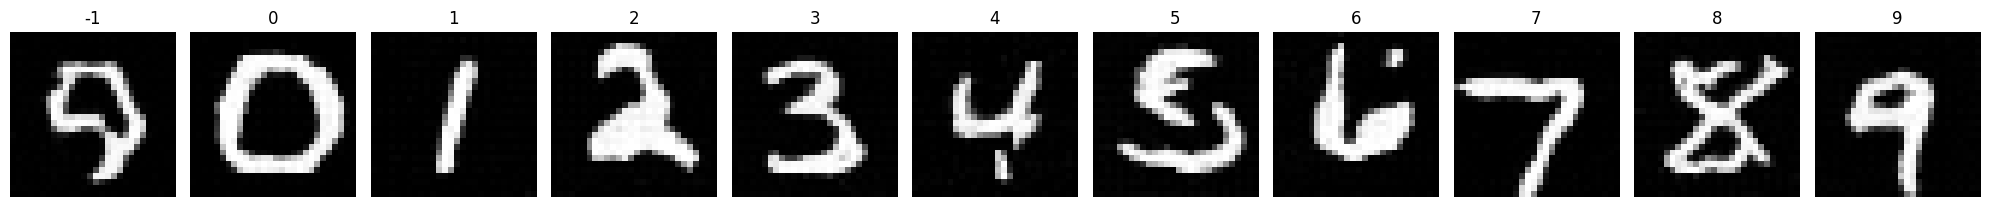

Epoch 13/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0311 - val_loss: 0.0467 - val_noise_loss: 0.0467 - val_image_loss: 0.2241 - learning_rate: 0.0048


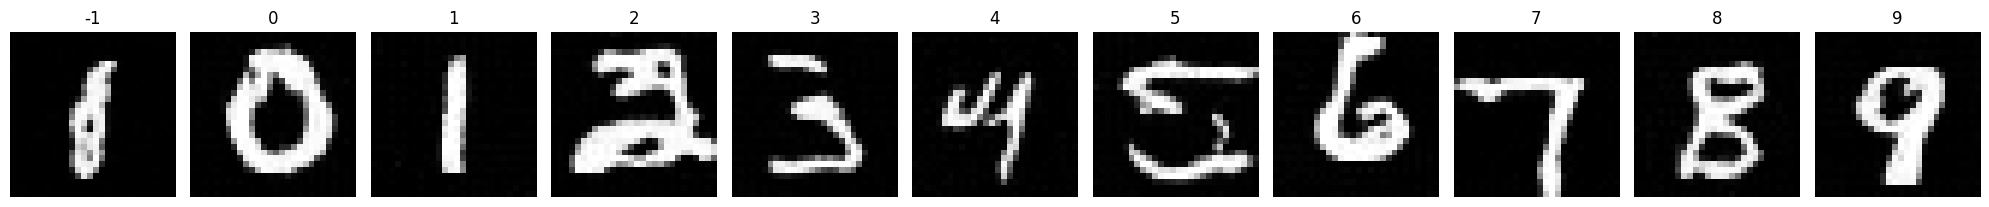

Epoch 14/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0307 - val_loss: 0.0475 - val_noise_loss: 0.0475 - val_image_loss: 0.2243 - learning_rate: 0.0048


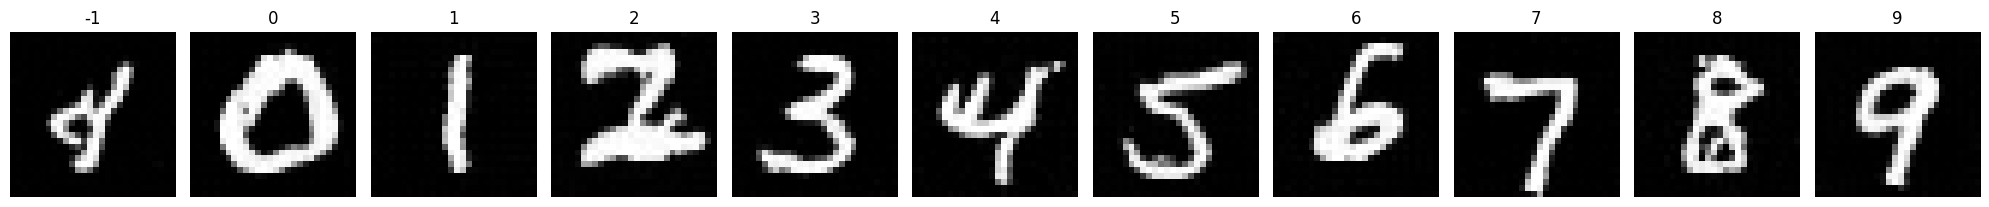

Epoch 15/100
468/468 [==============================] - 38s 81ms/step - noise_loss: 0.0303 - val_loss: 0.0483 - val_noise_loss: 0.0483 - val_image_loss: 0.2209 - learning_rate: 0.0047


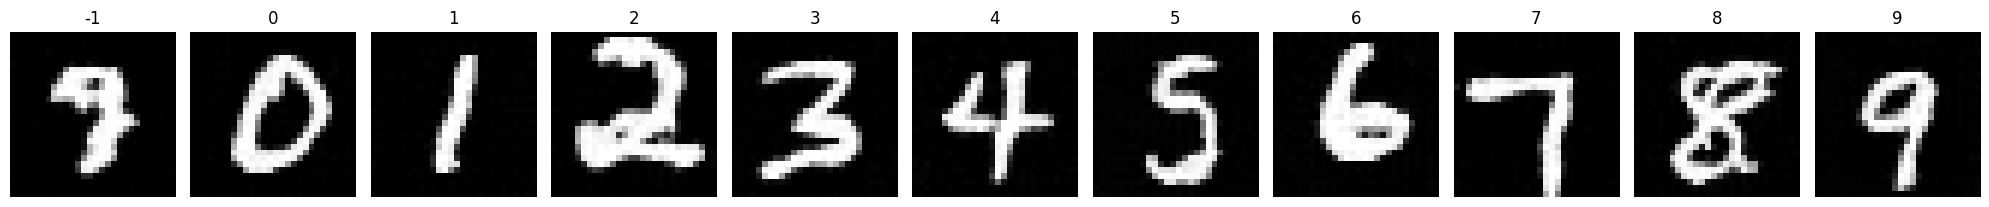

Epoch 16/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0303 - val_loss: 0.0486 - val_noise_loss: 0.0486 - val_image_loss: 0.2267 - learning_rate: 0.0047


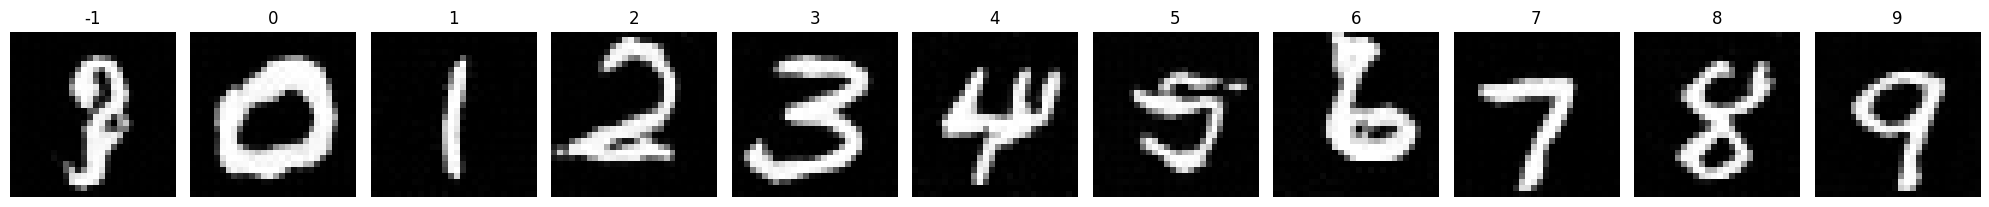

Epoch 17/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0301 - val_loss: 0.0485 - val_noise_loss: 0.0485 - val_image_loss: 0.2211 - learning_rate: 0.0047


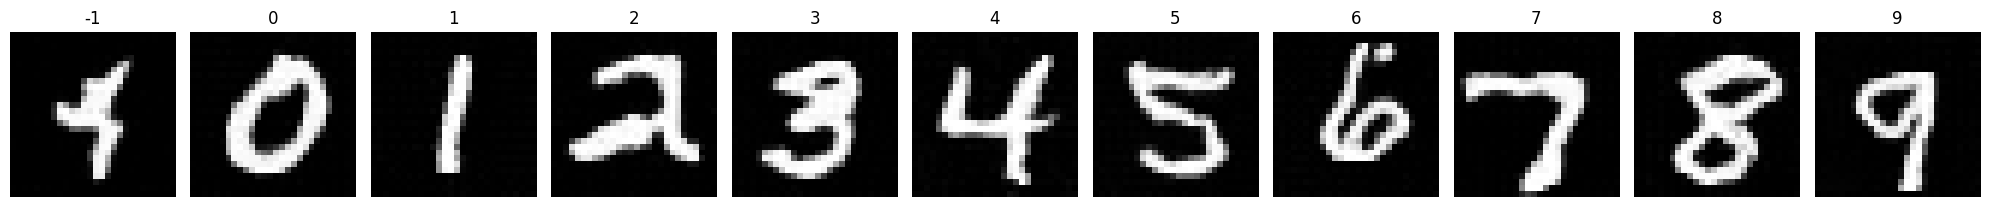

Epoch 18/100
468/468 [==============================] - 38s 81ms/step - noise_loss: 0.0300 - val_loss: 0.0486 - val_noise_loss: 0.0486 - val_image_loss: 0.2292 - learning_rate: 0.0046


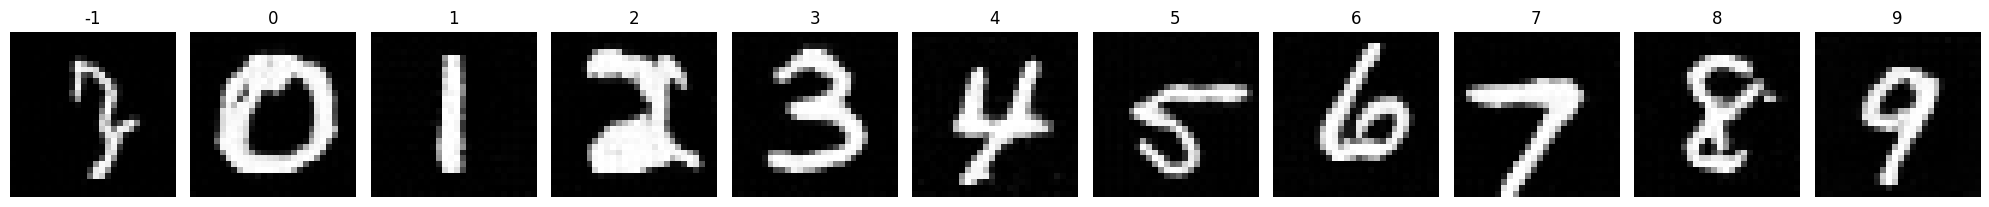

Epoch 19/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0297 - val_loss: 0.0484 - val_noise_loss: 0.0484 - val_image_loss: 0.2277 - learning_rate: 0.0046


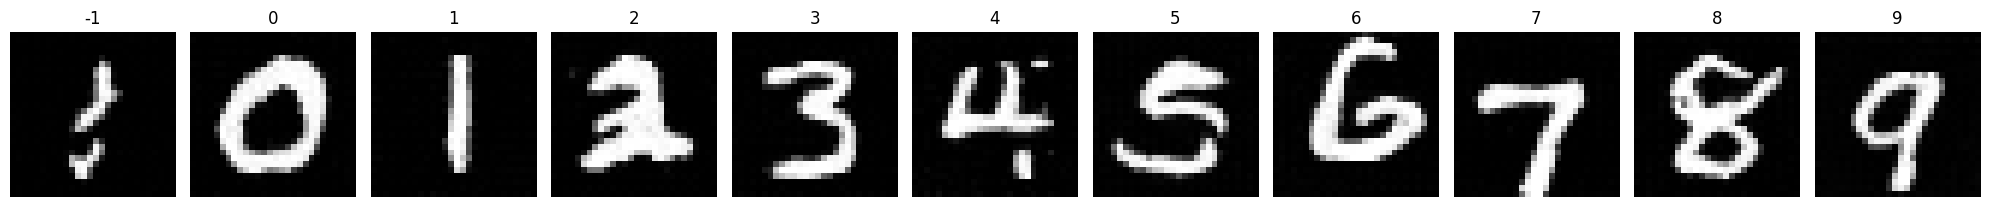

Epoch 20/100
468/468 [==============================] - 38s 80ms/step - noise_loss: 0.0296 - val_loss: 0.0480 - val_noise_loss: 0.0480 - val_image_loss: 0.2293 - learning_rate: 0.0045


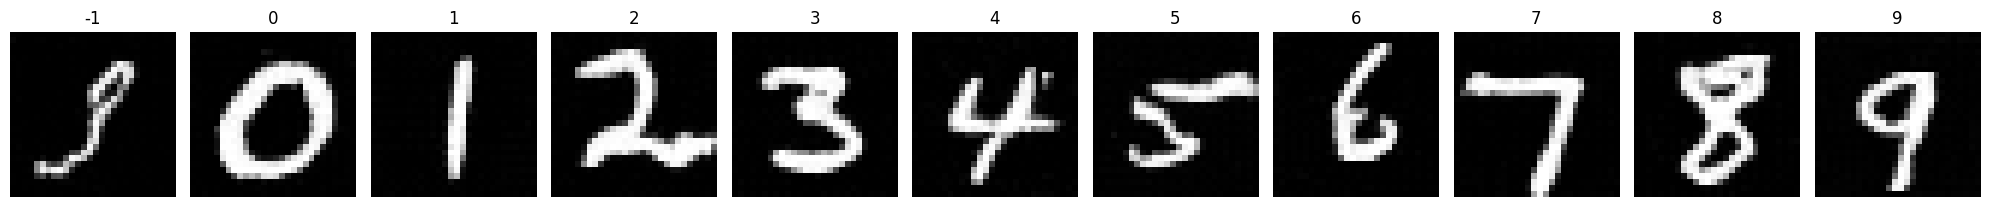

Epoch 21/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0293 - val_loss: 0.0483 - val_noise_loss: 0.0483 - val_image_loss: 0.2245 - learning_rate: 0.0045


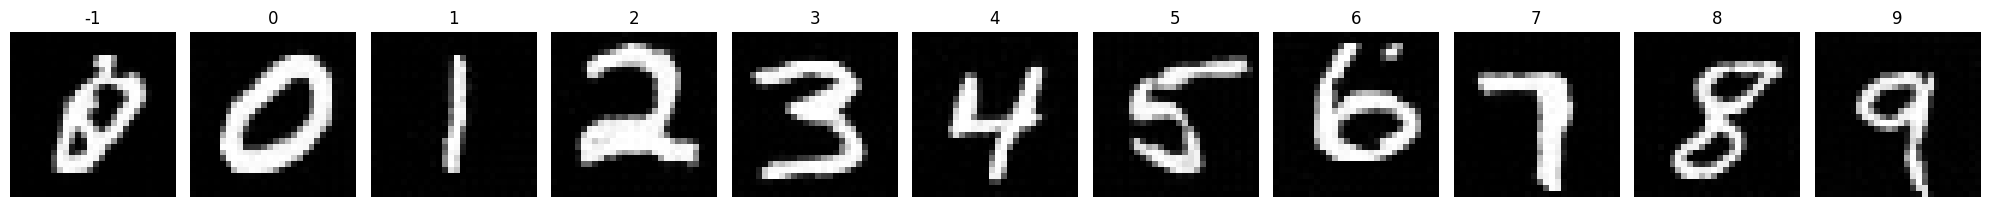

Epoch 22/100
468/468 [==============================] - 37s 78ms/step - noise_loss: 0.0296 - val_loss: 0.0483 - val_noise_loss: 0.0483 - val_image_loss: 0.2282 - learning_rate: 0.0044


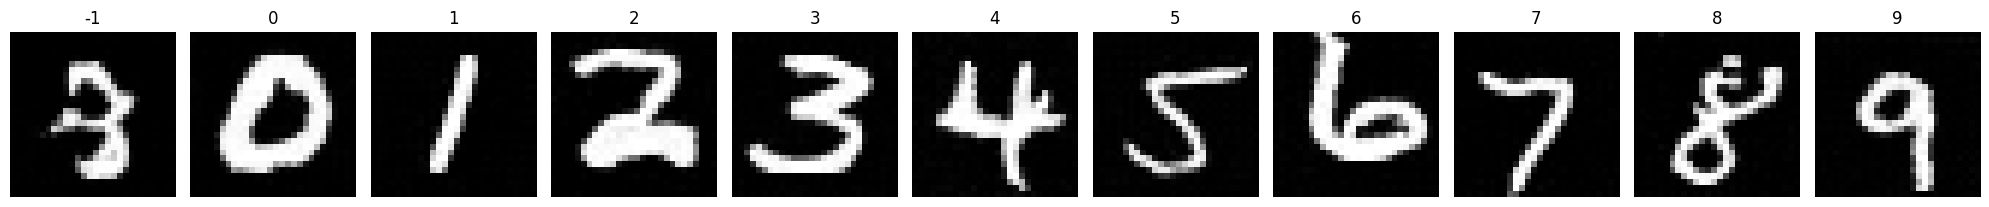

Epoch 23/100
468/468 [==============================] - 38s 80ms/step - noise_loss: 0.0293 - val_loss: 0.0481 - val_noise_loss: 0.0481 - val_image_loss: 0.2224 - learning_rate: 0.0044


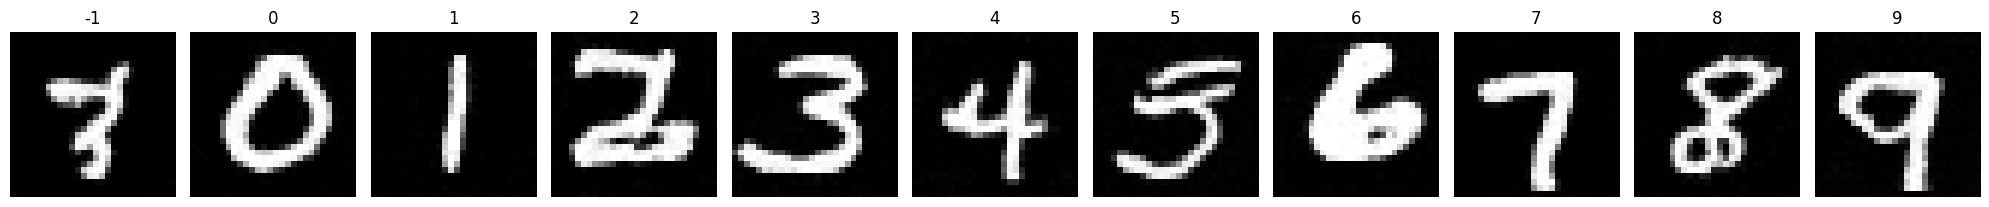

Epoch 24/100
468/468 [==============================] - 37s 80ms/step - noise_loss: 0.0291 - val_loss: 0.0477 - val_noise_loss: 0.0477 - val_image_loss: 0.2228 - learning_rate: 0.0043


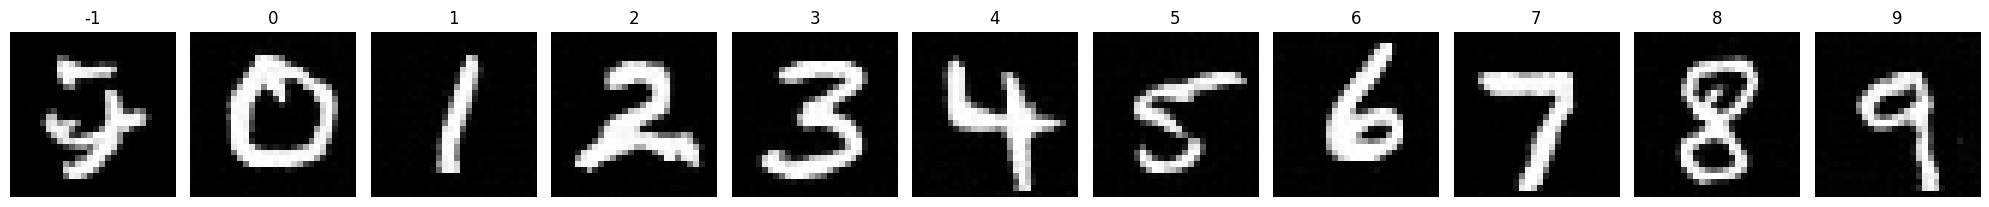

Epoch 25/100
468/468 [==============================] - 38s 80ms/step - noise_loss: 0.0291 - val_loss: 0.0483 - val_noise_loss: 0.0483 - val_image_loss: 0.2103 - learning_rate: 0.0043


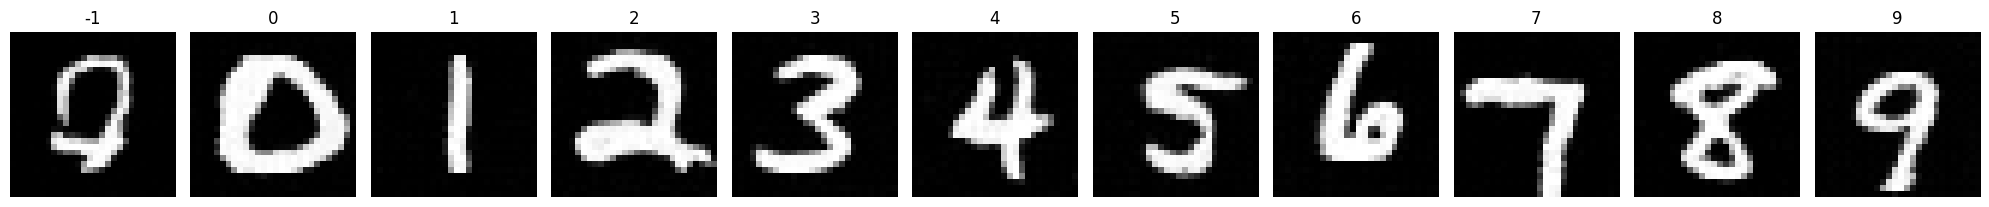

Epoch 26/100
468/468 [==============================] - 38s 80ms/step - noise_loss: 0.0291 - val_loss: 0.0474 - val_noise_loss: 0.0474 - val_image_loss: 0.2229 - learning_rate: 0.0042


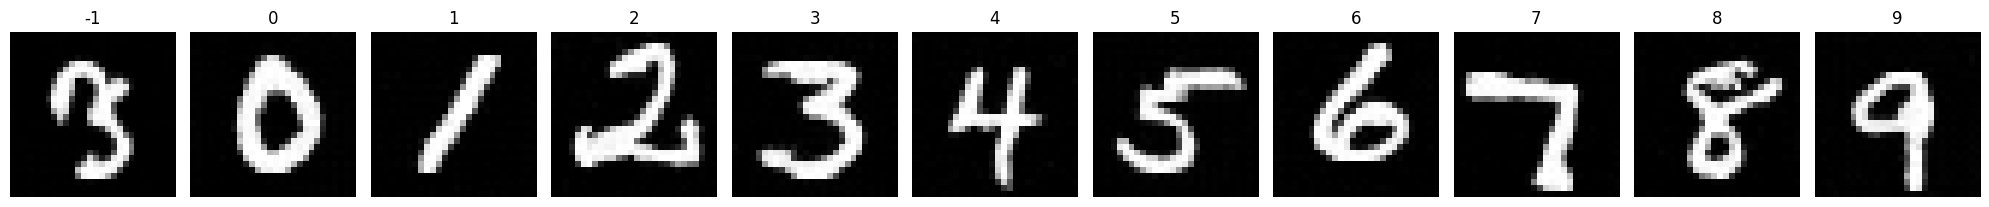

Epoch 27/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0289 - val_loss: 0.0474 - val_noise_loss: 0.0474 - val_image_loss: 0.2198 - learning_rate: 0.0042


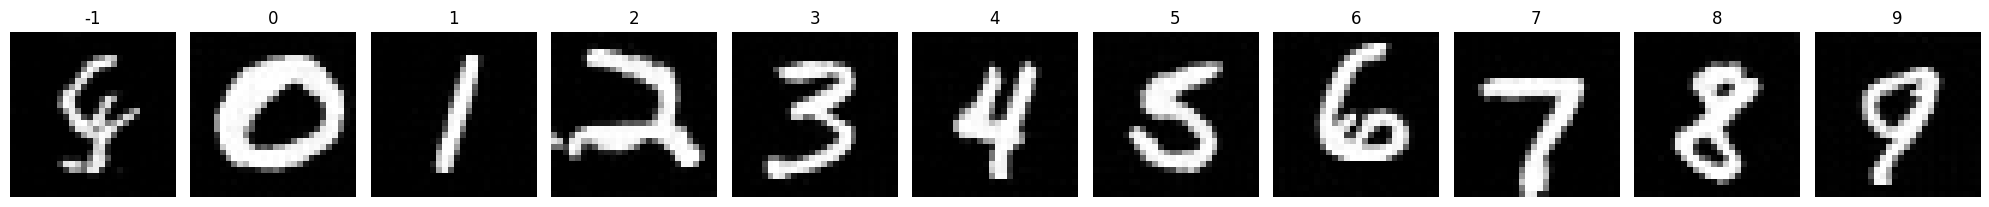

Epoch 28/100
468/468 [==============================] - 37s 80ms/step - noise_loss: 0.0288 - val_loss: 0.0473 - val_noise_loss: 0.0473 - val_image_loss: 0.2234 - learning_rate: 0.0041


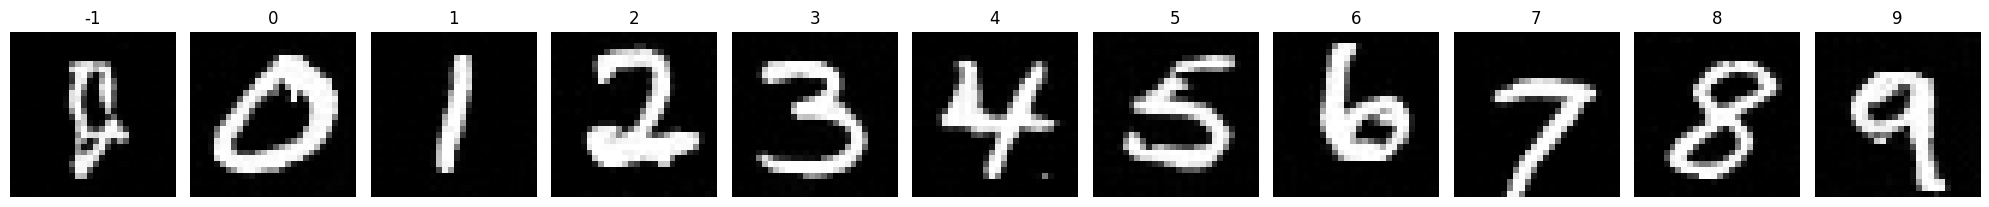

Epoch 29/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0287 - val_loss: 0.0474 - val_noise_loss: 0.0474 - val_image_loss: 0.2264 - learning_rate: 0.0040


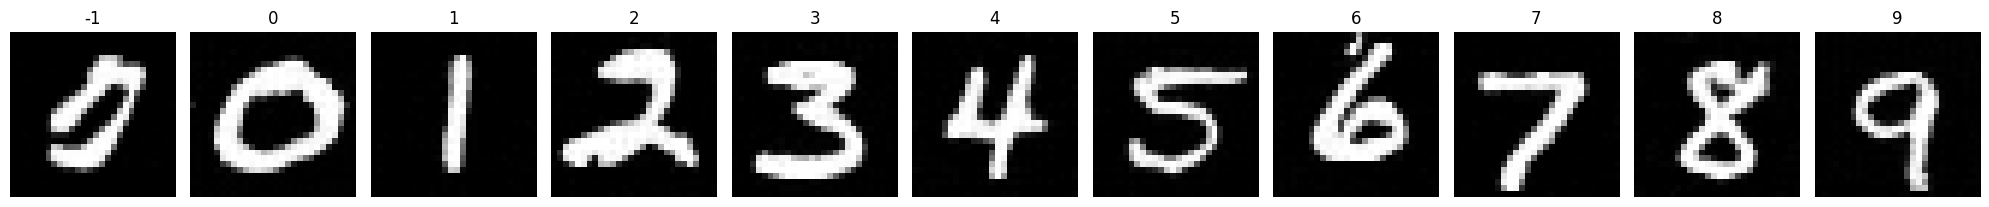

Epoch 30/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0285 - val_loss: 0.0476 - val_noise_loss: 0.0476 - val_image_loss: 0.2130 - learning_rate: 0.0040


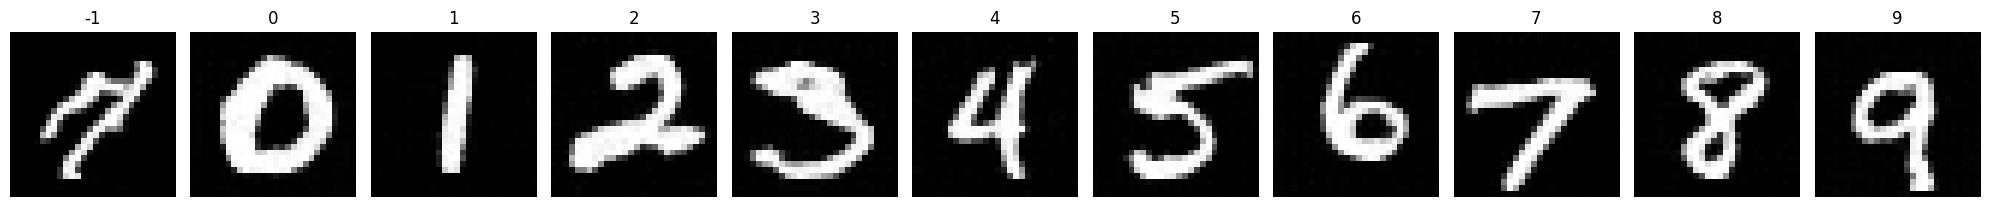

Epoch 31/100
468/468 [==============================] - 37s 78ms/step - noise_loss: 0.0286 - val_loss: 0.0475 - val_noise_loss: 0.0475 - val_image_loss: 0.2173 - learning_rate: 0.0039


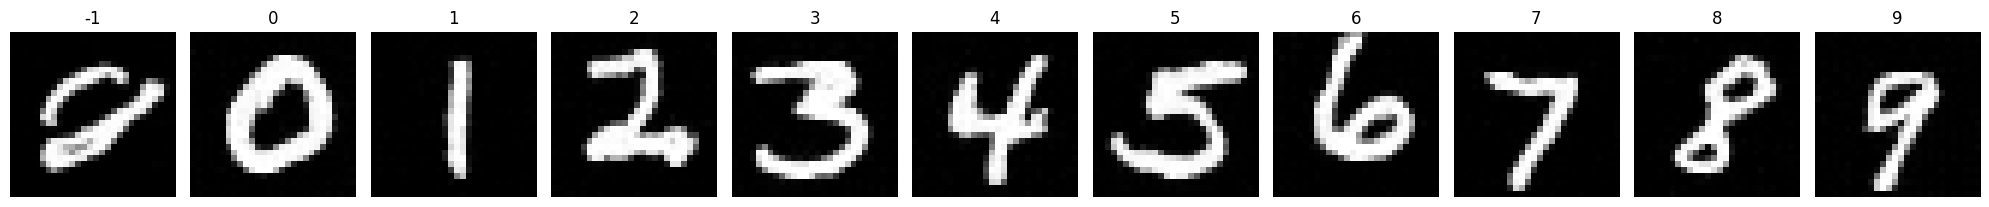

Epoch 32/100
468/468 [==============================] - 38s 80ms/step - noise_loss: 0.0283 - val_loss: 0.0471 - val_noise_loss: 0.0471 - val_image_loss: 0.2241 - learning_rate: 0.0038


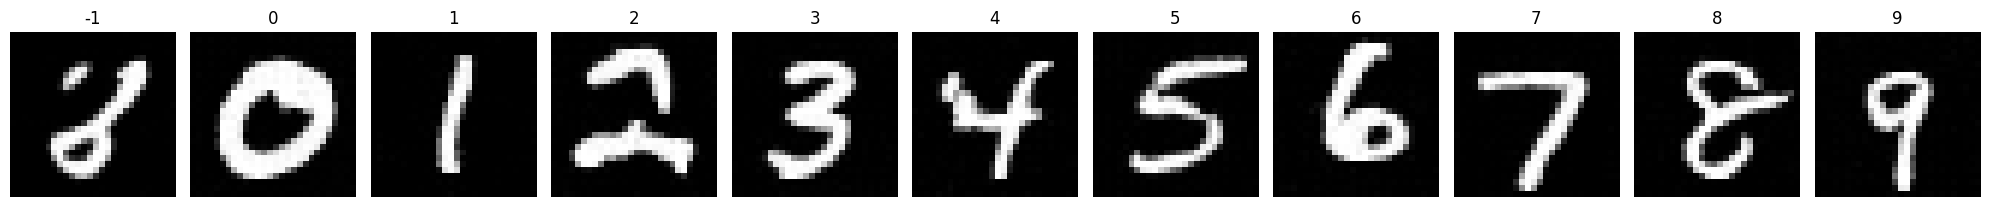

Epoch 33/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0284 - val_loss: 0.0473 - val_noise_loss: 0.0473 - val_image_loss: 0.2247 - learning_rate: 0.0038


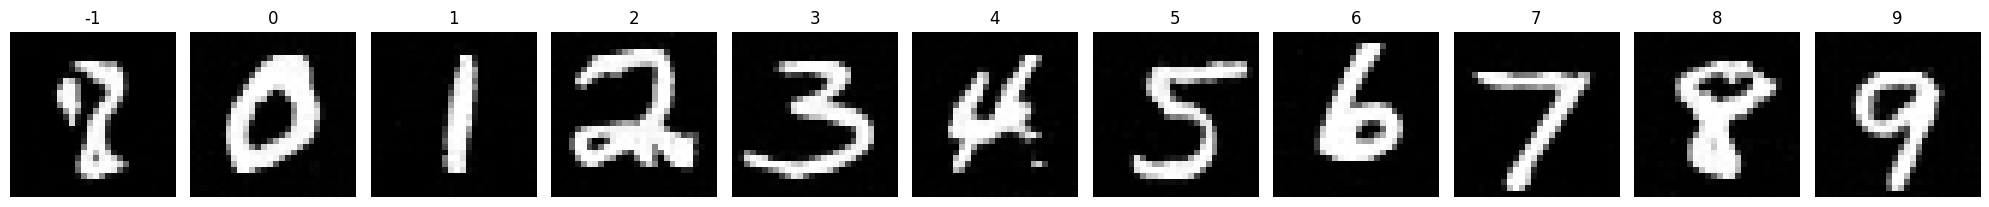

Epoch 34/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0282 - val_loss: 0.0468 - val_noise_loss: 0.0468 - val_image_loss: 0.2276 - learning_rate: 0.0037


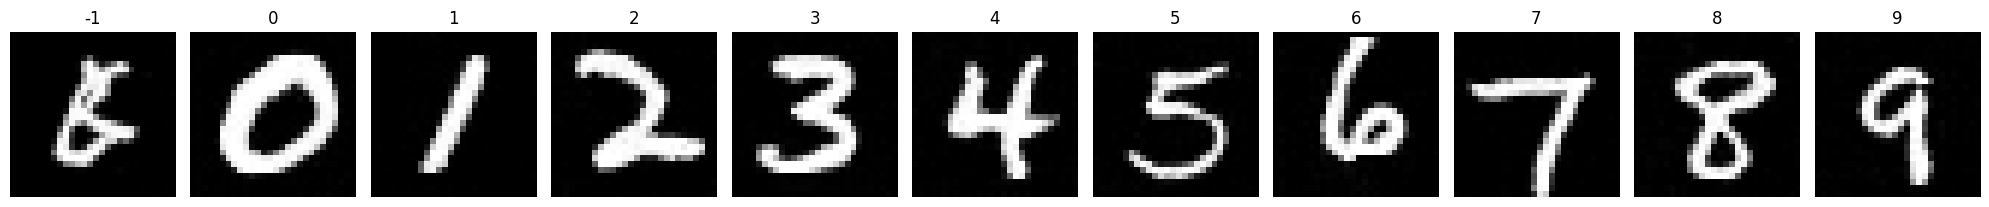

Epoch 35/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0283 - val_loss: 0.0469 - val_noise_loss: 0.0469 - val_image_loss: 0.2232 - learning_rate: 0.0036


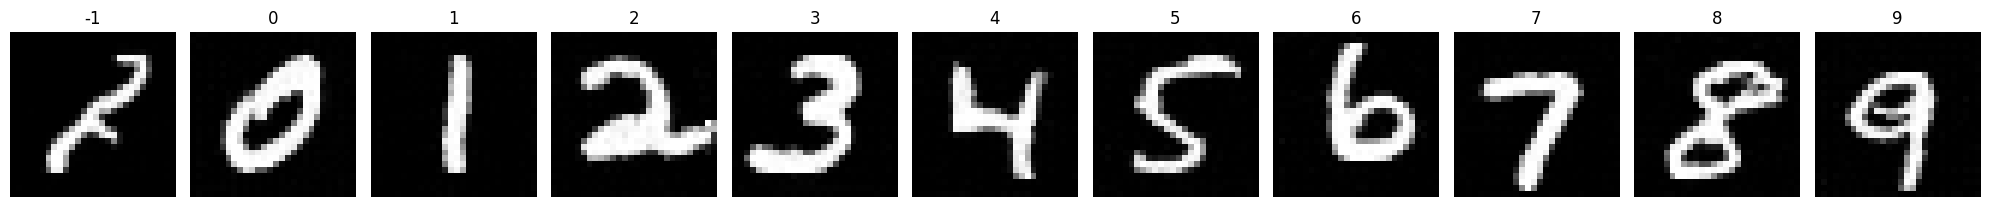

Epoch 36/100
468/468 [==============================] - 37s 78ms/step - noise_loss: 0.0281 - val_loss: 0.0470 - val_noise_loss: 0.0470 - val_image_loss: 0.2248 - learning_rate: 0.0036


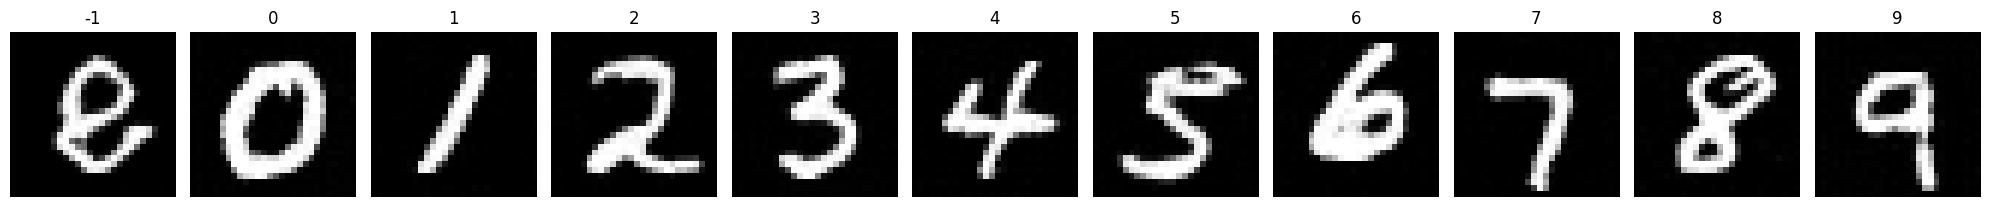

Epoch 37/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0281 - val_loss: 0.0470 - val_noise_loss: 0.0470 - val_image_loss: 0.2236 - learning_rate: 0.0035


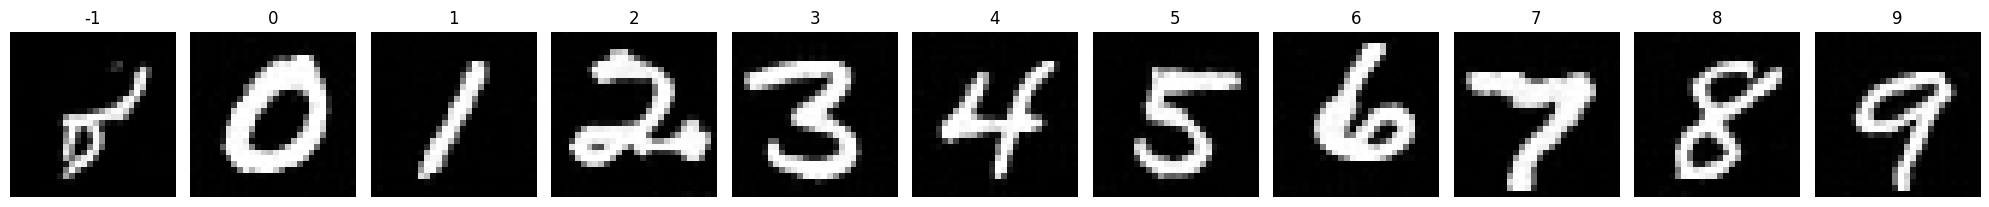

Epoch 38/100
468/468 [==============================] - 38s 81ms/step - noise_loss: 0.0281 - val_loss: 0.0474 - val_noise_loss: 0.0474 - val_image_loss: 0.2176 - learning_rate: 0.0034


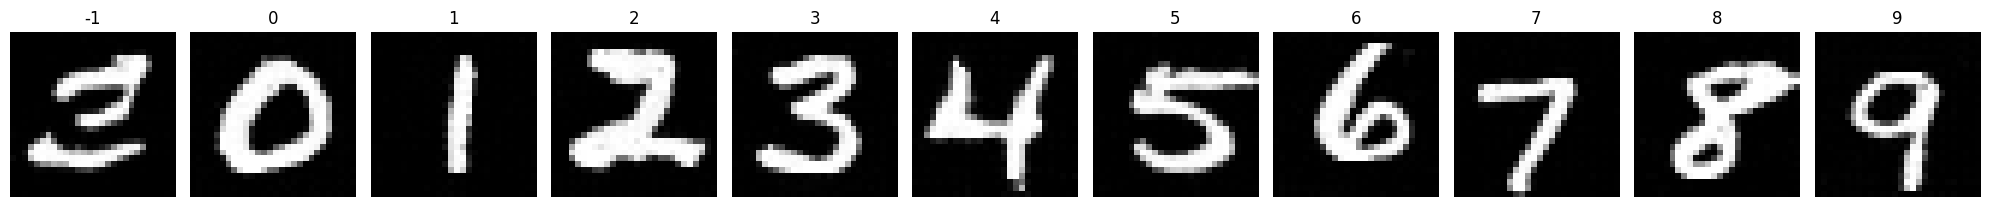

Epoch 39/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0280 - val_loss: 0.0477 - val_noise_loss: 0.0477 - val_image_loss: 0.2201 - learning_rate: 0.0033


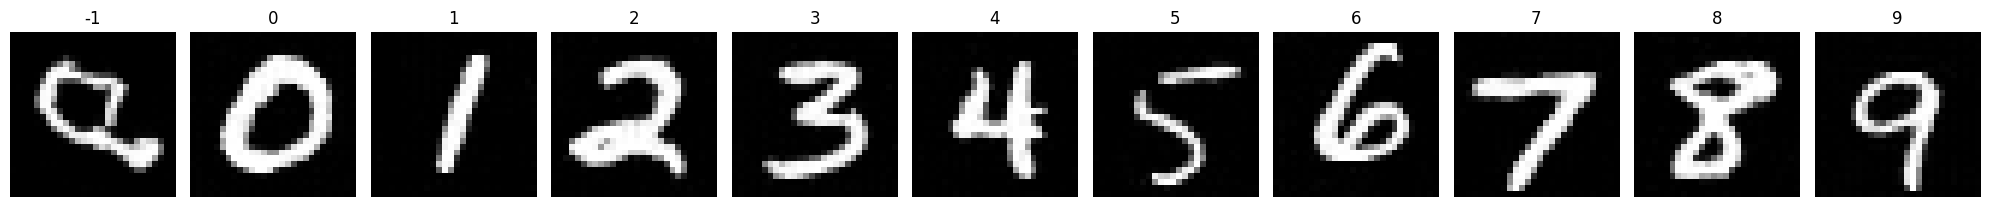

Epoch 40/100
468/468 [==============================] - 37s 80ms/step - noise_loss: 0.0279 - val_loss: 0.0477 - val_noise_loss: 0.0477 - val_image_loss: 0.2147 - learning_rate: 0.0033


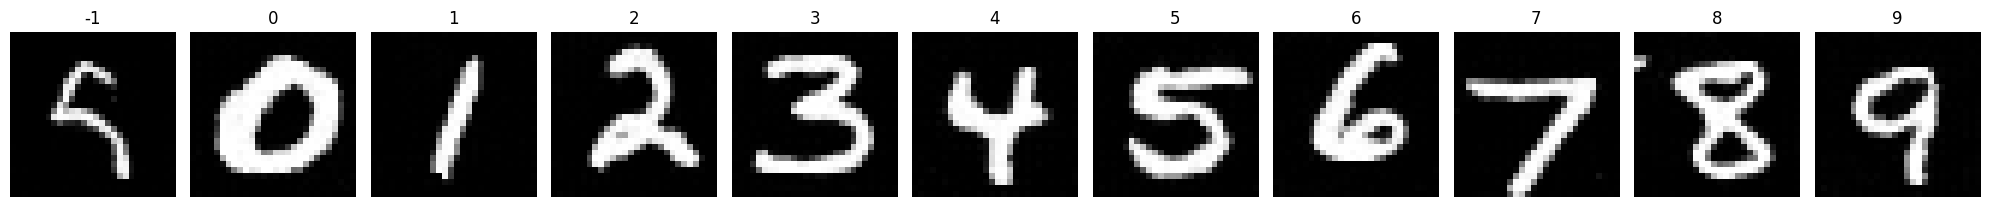

Epoch 41/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0278 - val_loss: 0.0475 - val_noise_loss: 0.0475 - val_image_loss: 0.2170 - learning_rate: 0.0032


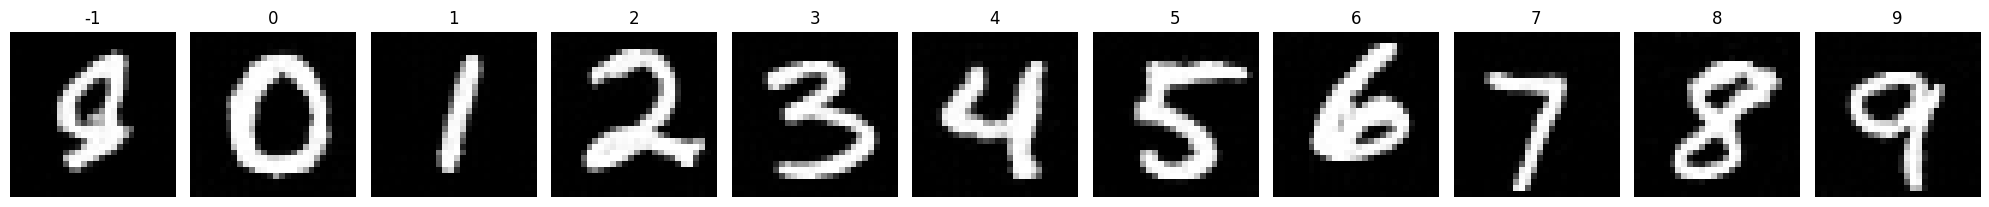

Epoch 42/100
468/468 [==============================] - 38s 80ms/step - noise_loss: 0.0277 - val_loss: 0.0480 - val_noise_loss: 0.0480 - val_image_loss: 0.2182 - learning_rate: 0.0031


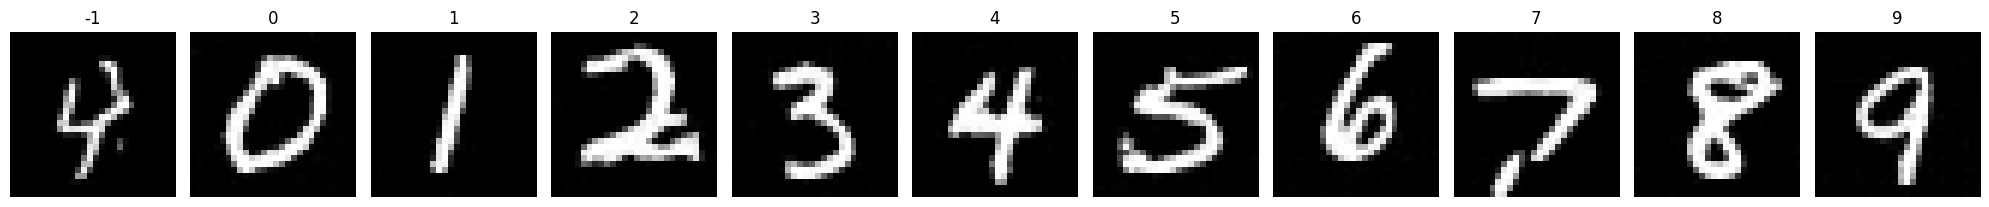

Epoch 43/100
468/468 [==============================] - 37s 80ms/step - noise_loss: 0.0278 - val_loss: 0.0472 - val_noise_loss: 0.0472 - val_image_loss: 0.2251 - learning_rate: 0.0030


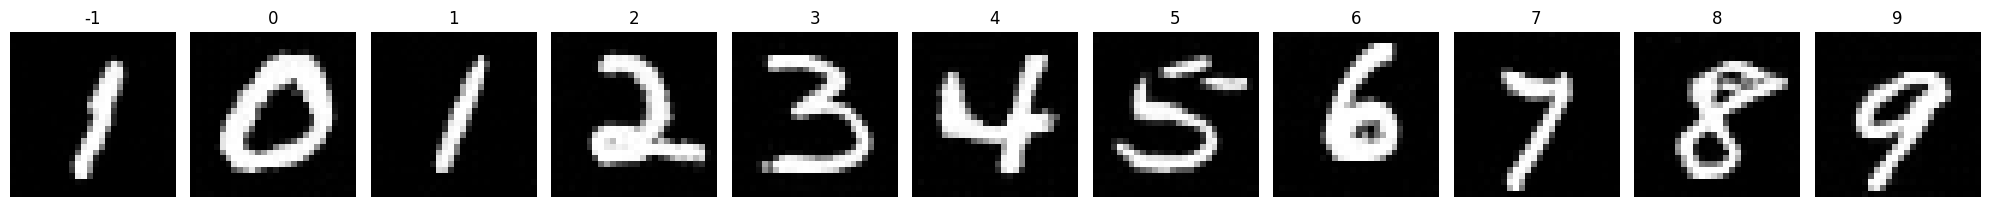

Epoch 44/100
468/468 [==============================] - 38s 81ms/step - noise_loss: 0.0278 - val_loss: 0.0475 - val_noise_loss: 0.0475 - val_image_loss: 0.2168 - learning_rate: 0.0030


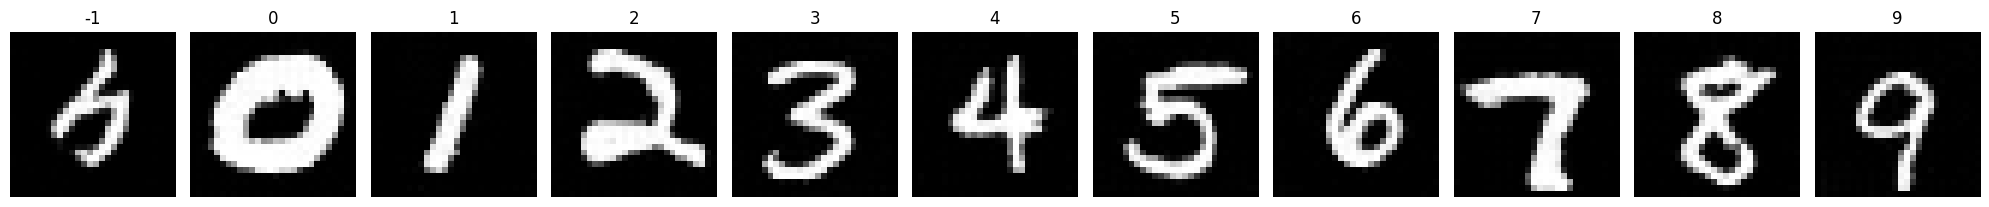

Epoch 45/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0277 - val_loss: 0.0475 - val_noise_loss: 0.0475 - val_image_loss: 0.2276 - learning_rate: 0.0029


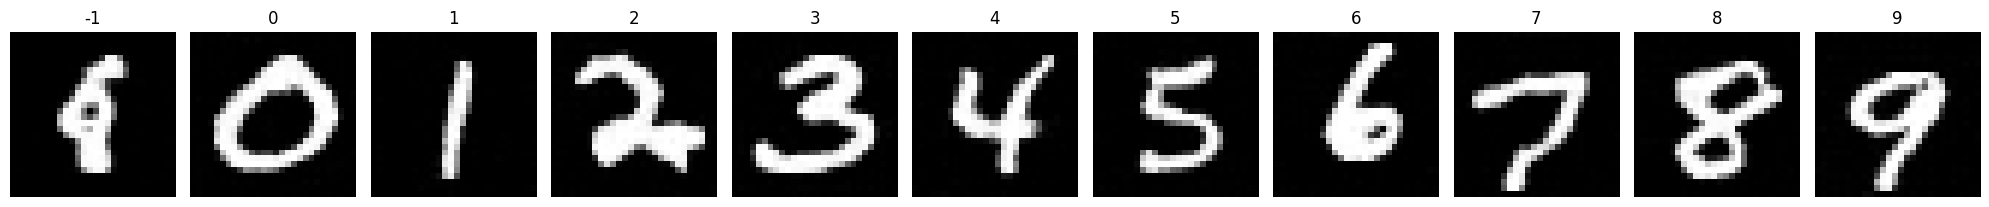

Epoch 46/100
468/468 [==============================] - 38s 80ms/step - noise_loss: 0.0277 - val_loss: 0.0476 - val_noise_loss: 0.0476 - val_image_loss: 0.2189 - learning_rate: 0.0028


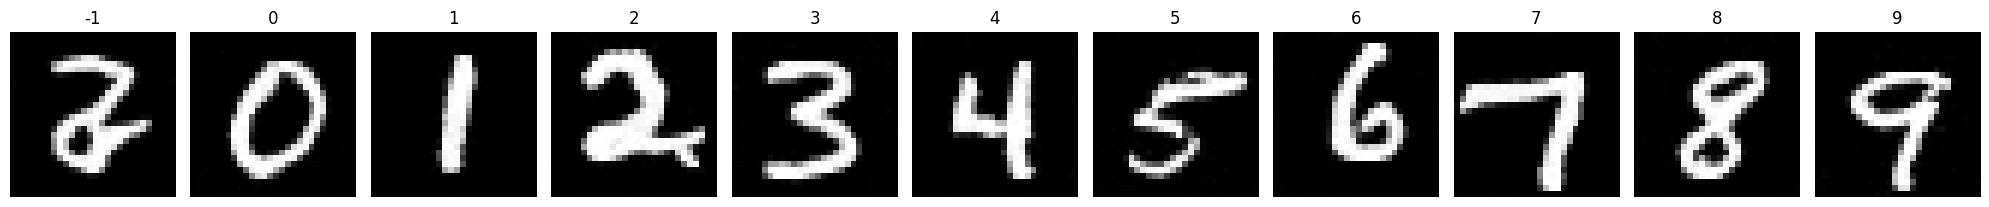

Epoch 47/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0276 - val_loss: 0.0473 - val_noise_loss: 0.0473 - val_image_loss: 0.2205 - learning_rate: 0.0027


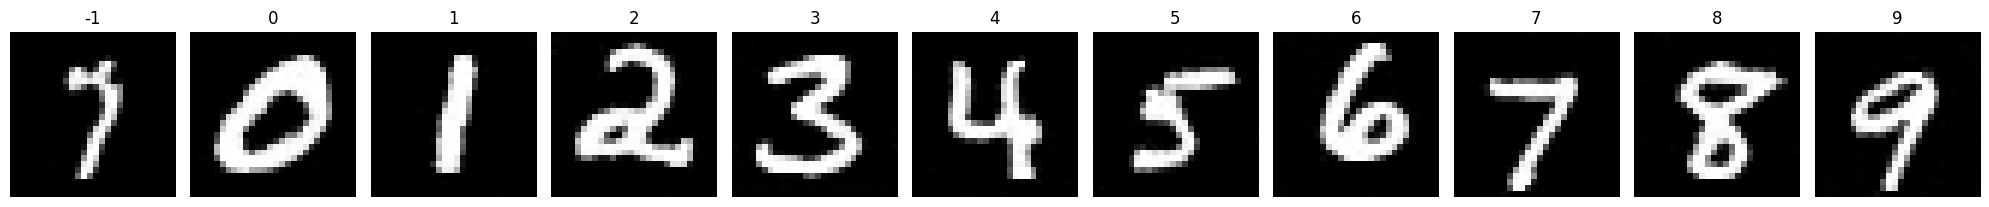

Epoch 48/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0275 - val_loss: 0.0474 - val_noise_loss: 0.0474 - val_image_loss: 0.2132 - learning_rate: 0.0027


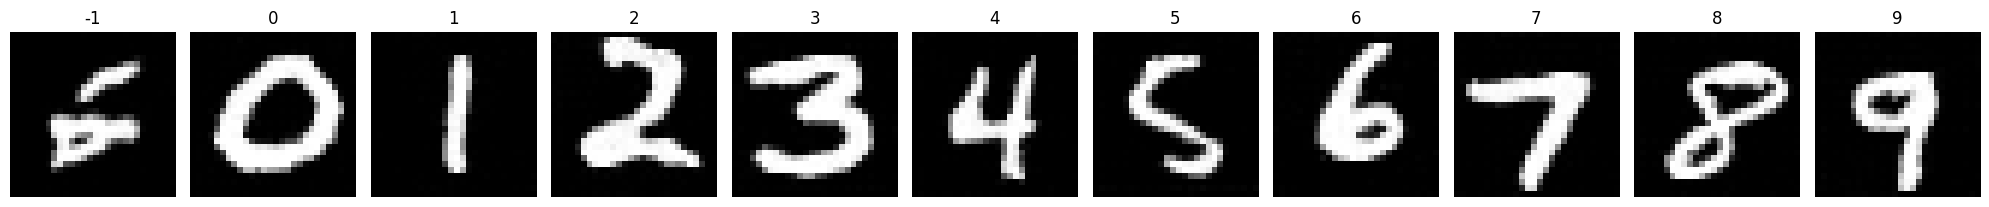

Epoch 49/100
468/468 [==============================] - 38s 81ms/step - noise_loss: 0.0275 - val_loss: 0.0473 - val_noise_loss: 0.0473 - val_image_loss: 0.2229 - learning_rate: 0.0026


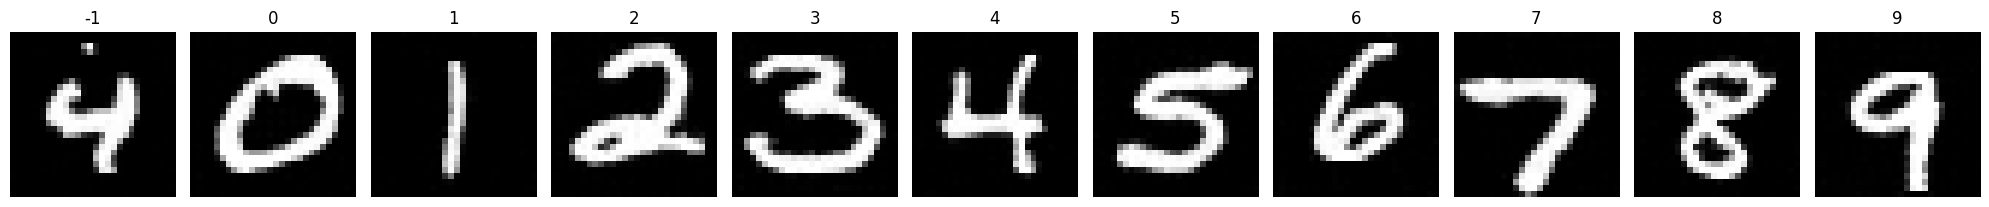

Epoch 50/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0275 - val_loss: 0.0473 - val_noise_loss: 0.0473 - val_image_loss: 0.2184 - learning_rate: 0.0025


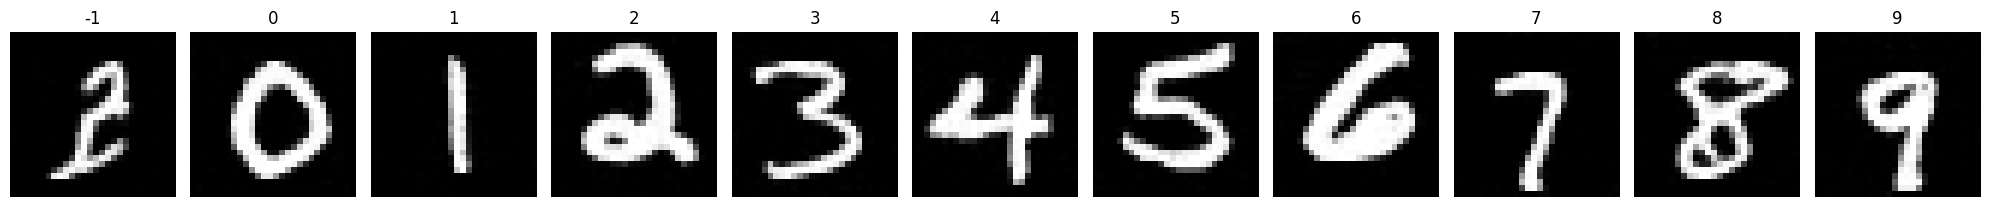

Epoch 51/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0275 - val_loss: 0.0477 - val_noise_loss: 0.0477 - val_image_loss: 0.2189 - learning_rate: 0.0024


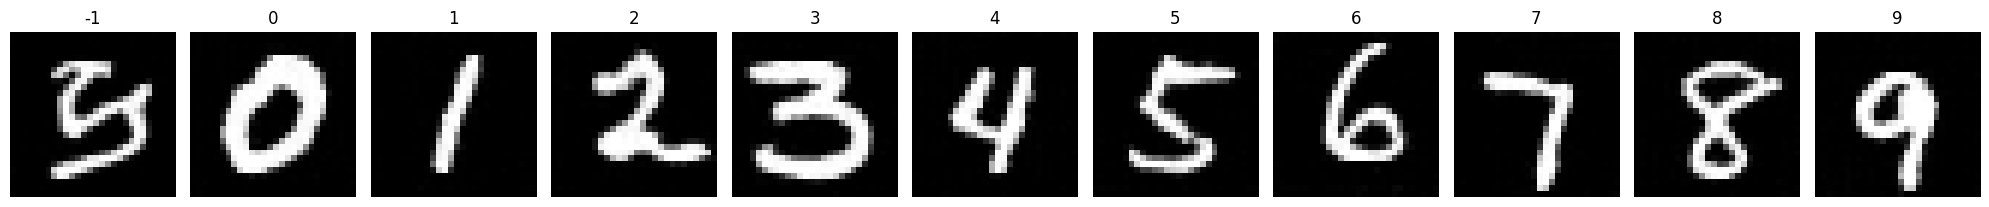

Epoch 52/100
468/468 [==============================] - 32s 68ms/step - noise_loss: 0.0274 - val_loss: 0.0474 - val_noise_loss: 0.0474 - val_image_loss: 0.2226 - learning_rate: 0.0023


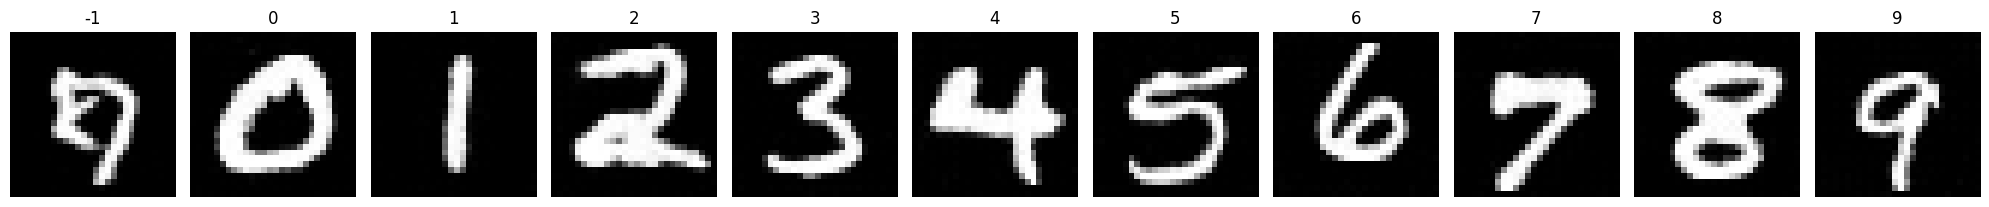

Epoch 53/100
468/468 [==============================] - 32s 68ms/step - noise_loss: 0.0273 - val_loss: 0.0477 - val_noise_loss: 0.0477 - val_image_loss: 0.2236 - learning_rate: 0.0023


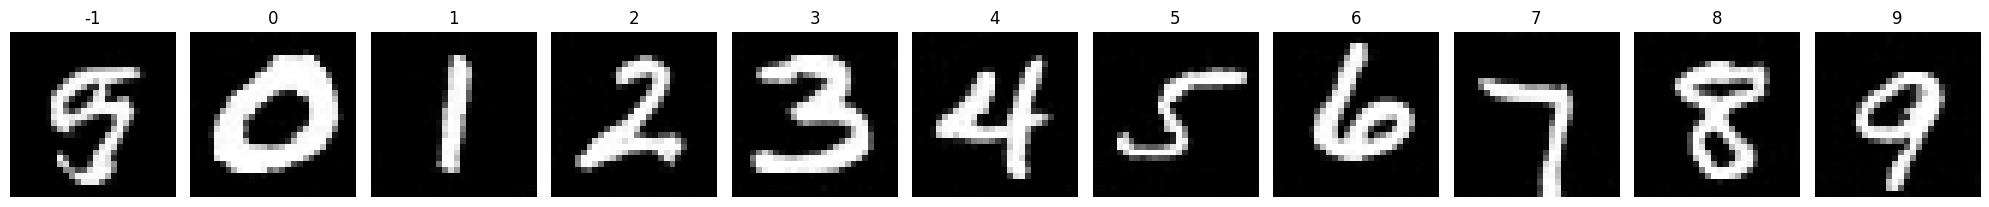

Epoch 54/100
468/468 [==============================] - 32s 67ms/step - noise_loss: 0.0272 - val_loss: 0.0474 - val_noise_loss: 0.0474 - val_image_loss: 0.2205 - learning_rate: 0.0022


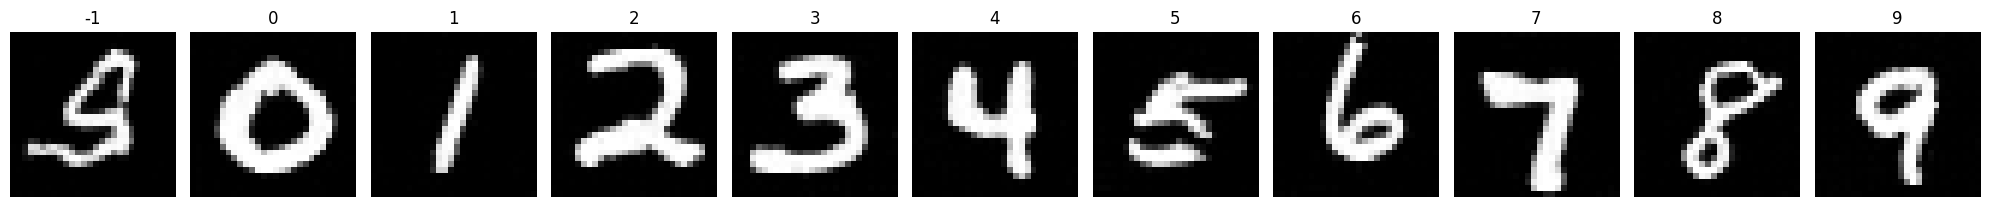

Epoch 55/100
468/468 [==============================] - 32s 68ms/step - noise_loss: 0.0272 - val_loss: 0.0475 - val_noise_loss: 0.0475 - val_image_loss: 0.2225 - learning_rate: 0.0021


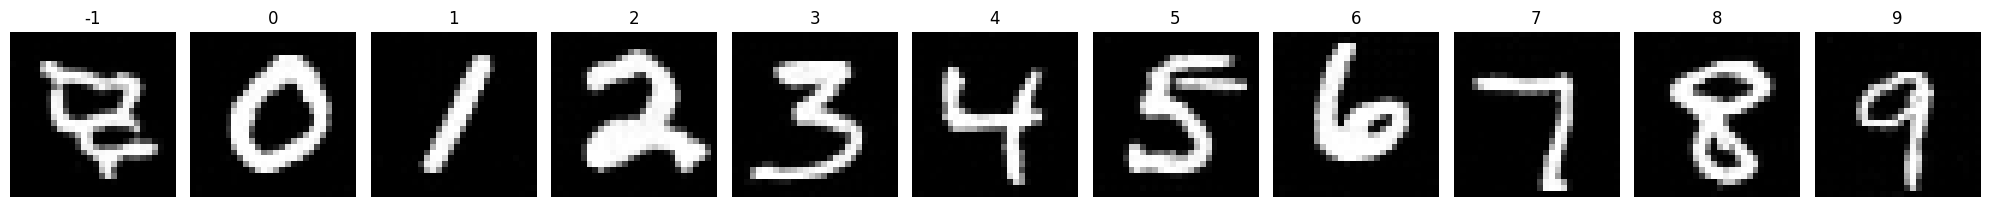

Epoch 56/100
468/468 [==============================] - 32s 67ms/step - noise_loss: 0.0271 - val_loss: 0.0475 - val_noise_loss: 0.0475 - val_image_loss: 0.2255 - learning_rate: 0.0020


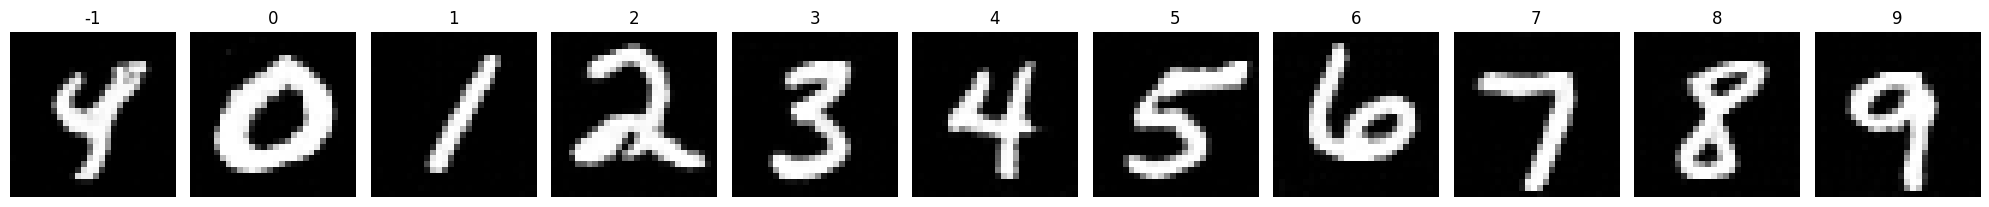

Epoch 57/100
468/468 [==============================] - 32s 68ms/step - noise_loss: 0.0271 - val_loss: 0.0478 - val_noise_loss: 0.0478 - val_image_loss: 0.2244 - learning_rate: 0.0020


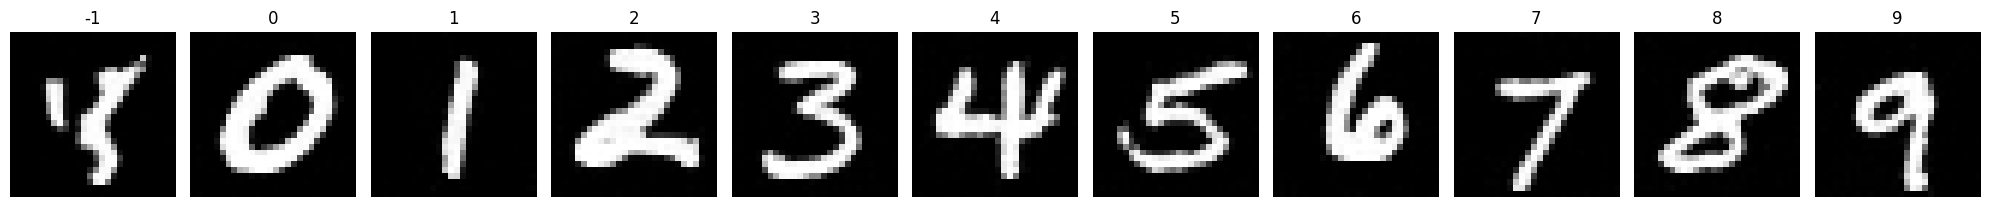

Epoch 58/100
468/468 [==============================] - 32s 68ms/step - noise_loss: 0.0272 - val_loss: 0.0473 - val_noise_loss: 0.0473 - val_image_loss: 0.2254 - learning_rate: 0.0019


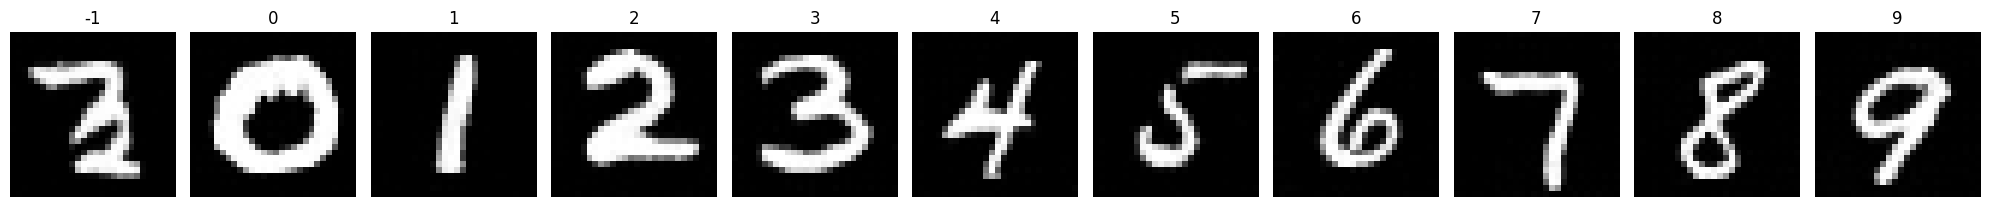

Epoch 59/100
468/468 [==============================] - 32s 68ms/step - noise_loss: 0.0269 - val_loss: 0.0477 - val_noise_loss: 0.0477 - val_image_loss: 0.2209 - learning_rate: 0.0018


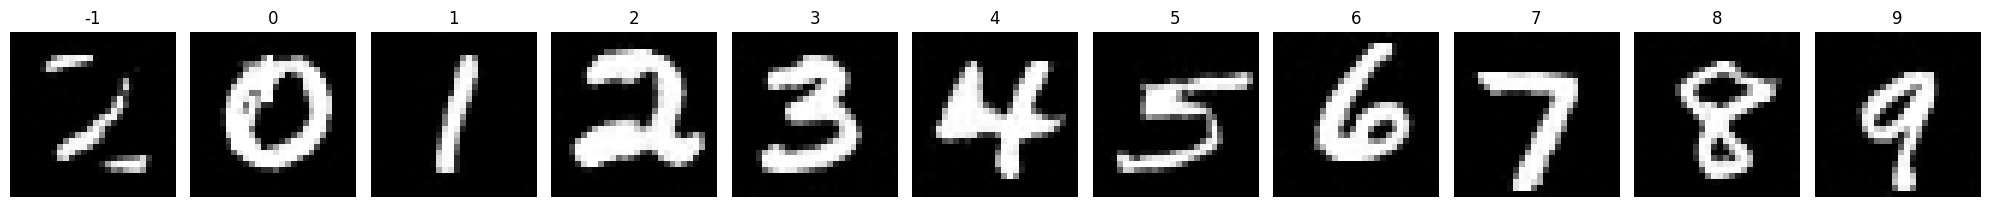

Epoch 60/100
468/468 [==============================] - 32s 69ms/step - noise_loss: 0.0270 - val_loss: 0.0479 - val_noise_loss: 0.0479 - val_image_loss: 0.2227 - learning_rate: 0.0017


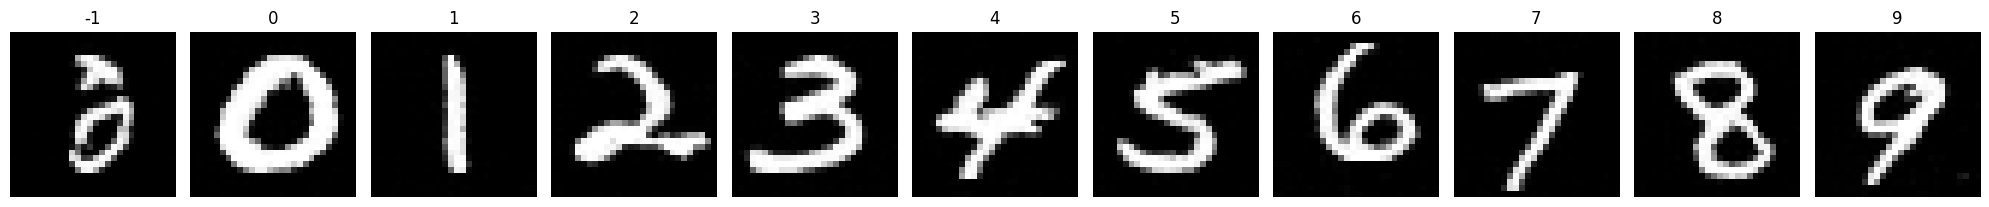

Epoch 61/100
468/468 [==============================] - 32s 68ms/step - noise_loss: 0.0271 - val_loss: 0.0476 - val_noise_loss: 0.0476 - val_image_loss: 0.2190 - learning_rate: 0.0017


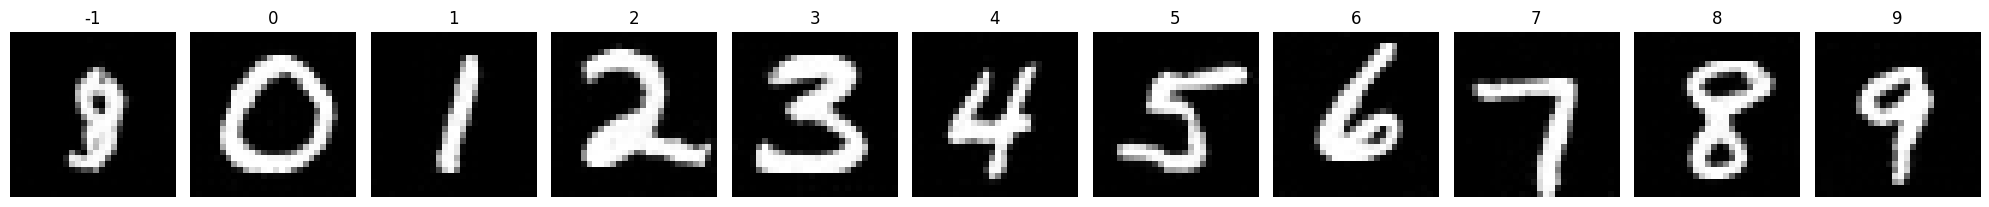

Epoch 62/100
468/468 [==============================] - 32s 68ms/step - noise_loss: 0.0270 - val_loss: 0.0475 - val_noise_loss: 0.0475 - val_image_loss: 0.2214 - learning_rate: 0.0016


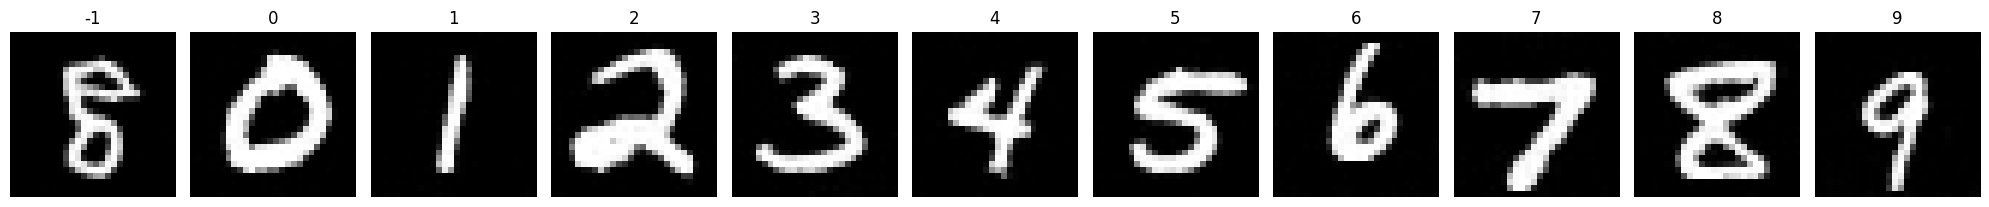

Epoch 63/100
468/468 [==============================] - 32s 68ms/step - noise_loss: 0.0269 - val_loss: 0.0478 - val_noise_loss: 0.0478 - val_image_loss: 0.2184 - learning_rate: 0.0015


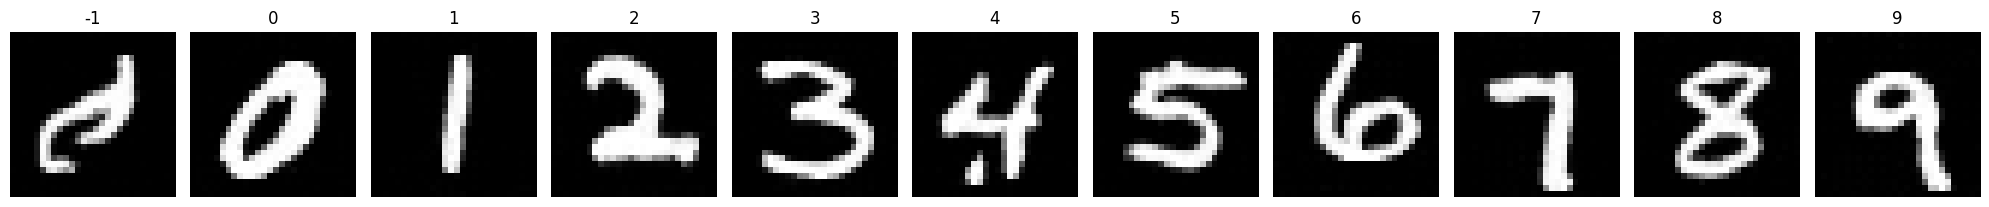

Epoch 64/100
468/468 [==============================] - 32s 69ms/step - noise_loss: 0.0269 - val_loss: 0.0473 - val_noise_loss: 0.0473 - val_image_loss: 0.2279 - learning_rate: 0.0014


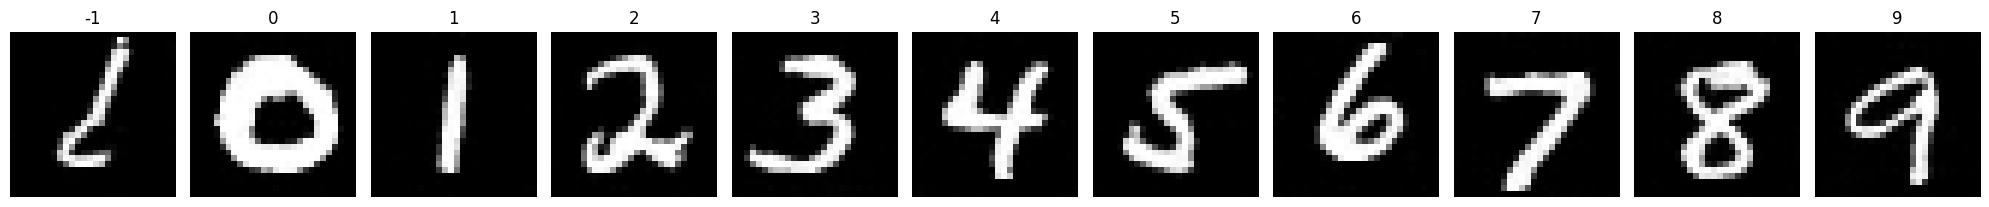

Epoch 65/100
468/468 [==============================] - 32s 68ms/step - noise_loss: 0.0267 - val_loss: 0.0479 - val_noise_loss: 0.0479 - val_image_loss: 0.2301 - learning_rate: 0.0014


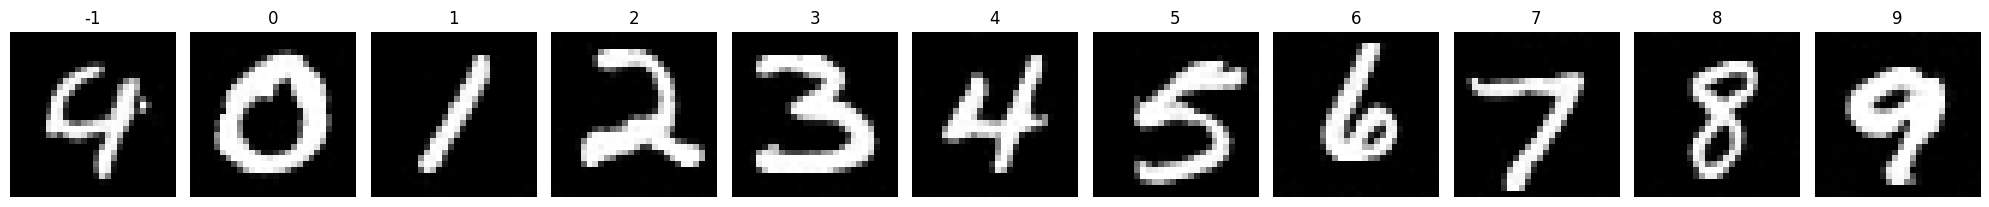

Epoch 66/100
468/468 [==============================] - 32s 67ms/step - noise_loss: 0.0268 - val_loss: 0.0479 - val_noise_loss: 0.0479 - val_image_loss: 0.2242 - learning_rate: 0.0013


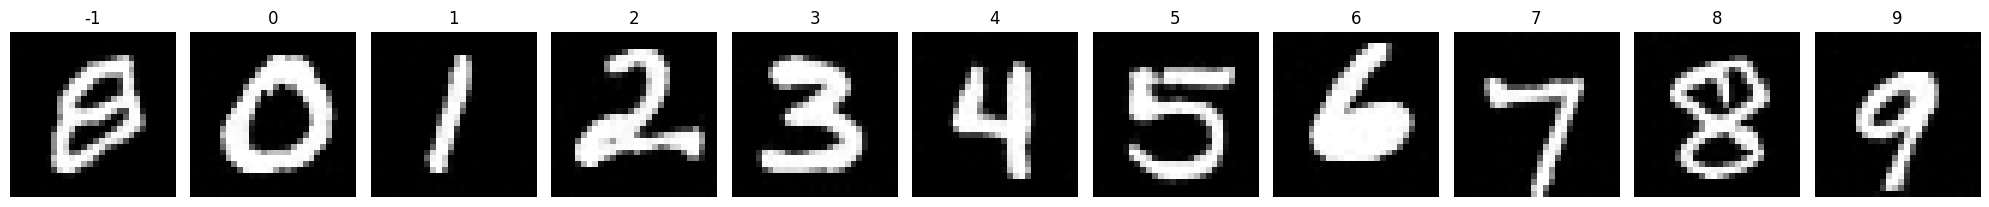

Epoch 67/100
468/468 [==============================] - 32s 68ms/step - noise_loss: 0.0266 - val_loss: 0.0478 - val_noise_loss: 0.0478 - val_image_loss: 0.2213 - learning_rate: 0.0012


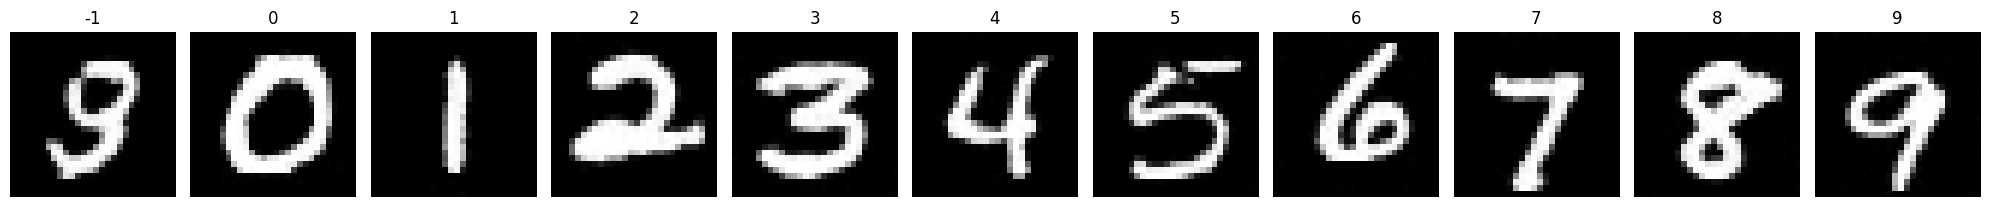

Epoch 68/100
468/468 [==============================] - 32s 68ms/step - noise_loss: 0.0268 - val_loss: 0.0484 - val_noise_loss: 0.0484 - val_image_loss: 0.2213 - learning_rate: 0.0012


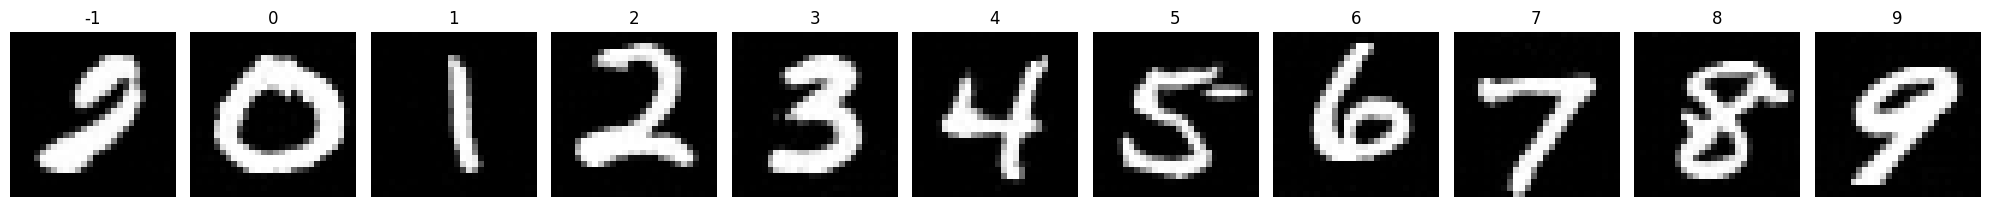

Epoch 69/100
468/468 [==============================] - 32s 68ms/step - noise_loss: 0.0266 - val_loss: 0.0475 - val_noise_loss: 0.0475 - val_image_loss: 0.2277 - learning_rate: 0.0011


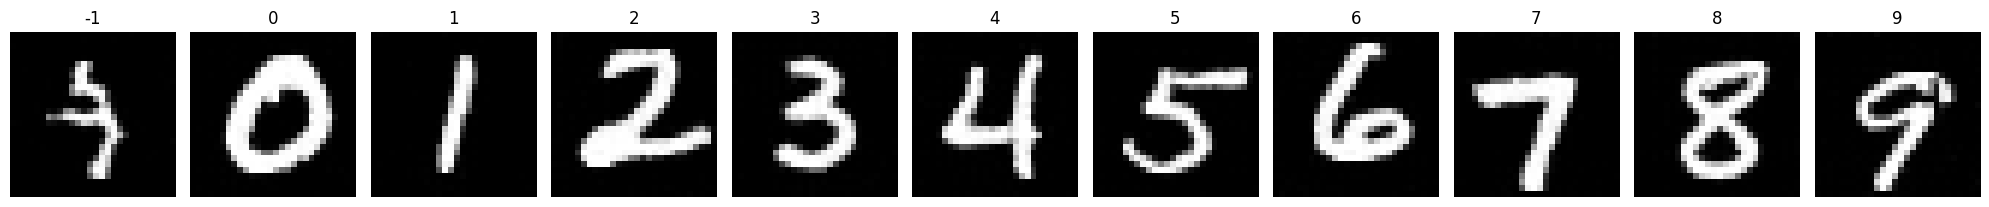

Epoch 70/100
468/468 [==============================] - 32s 69ms/step - noise_loss: 0.0266 - val_loss: 0.0478 - val_noise_loss: 0.0478 - val_image_loss: 0.2229 - learning_rate: 0.0010


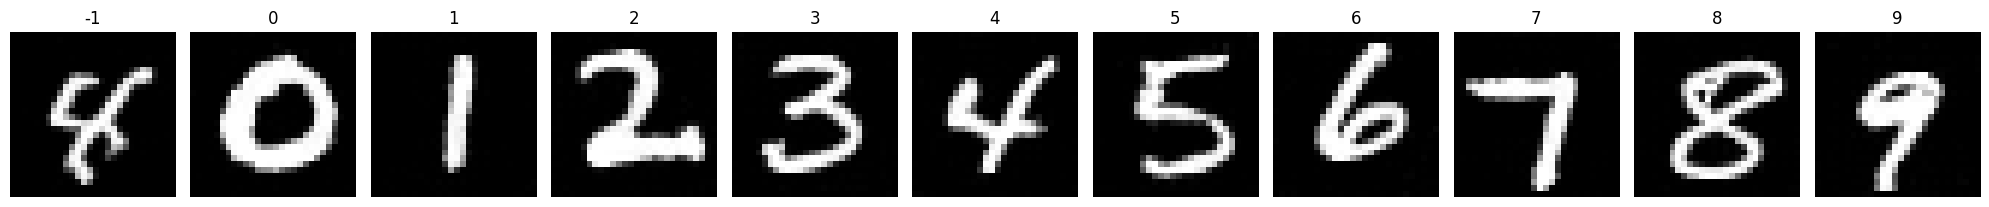

Epoch 71/100
468/468 [==============================] - 32s 68ms/step - noise_loss: 0.0268 - val_loss: 0.0474 - val_noise_loss: 0.0474 - val_image_loss: 0.2254 - learning_rate: 9.6773e-04


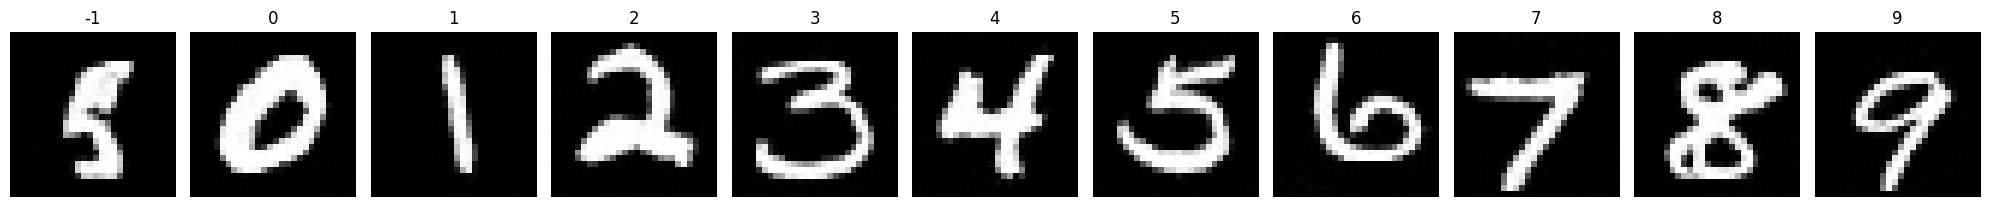

Epoch 72/100
468/468 [==============================] - 32s 68ms/step - noise_loss: 0.0265 - val_loss: 0.0474 - val_noise_loss: 0.0474 - val_image_loss: 0.2255 - learning_rate: 9.0644e-04


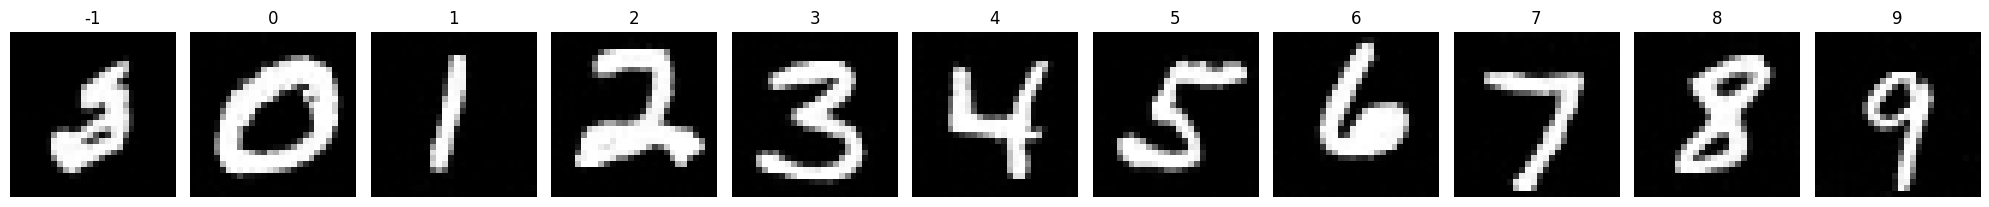

Epoch 73/100
468/468 [==============================] - 32s 68ms/step - noise_loss: 0.0267 - val_loss: 0.0475 - val_noise_loss: 0.0475 - val_image_loss: 0.2258 - learning_rate: 8.4672e-04


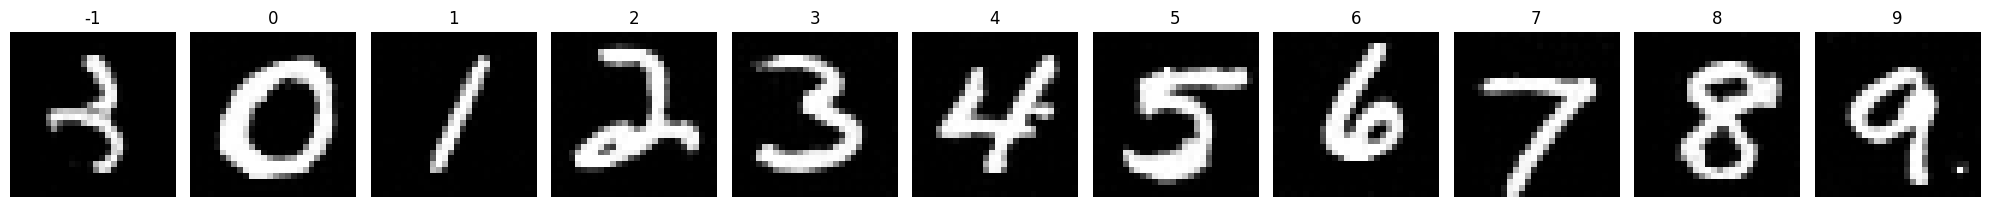

Epoch 74/100
468/468 [==============================] - 32s 68ms/step - noise_loss: 0.0264 - val_loss: 0.0479 - val_noise_loss: 0.0479 - val_image_loss: 0.2234 - learning_rate: 7.8863e-04


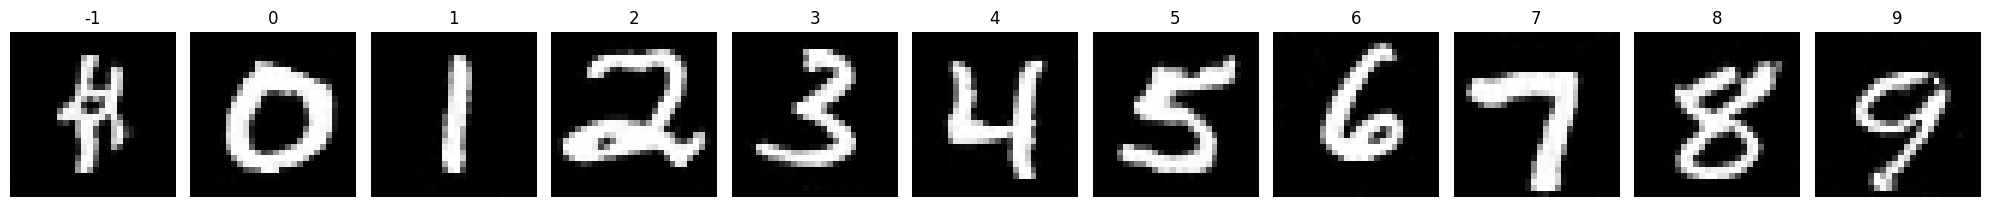

Epoch 75/100
468/468 [==============================] - 32s 69ms/step - noise_loss: 0.0265 - val_loss: 0.0481 - val_noise_loss: 0.0481 - val_image_loss: 0.2247 - learning_rate: 7.3223e-04


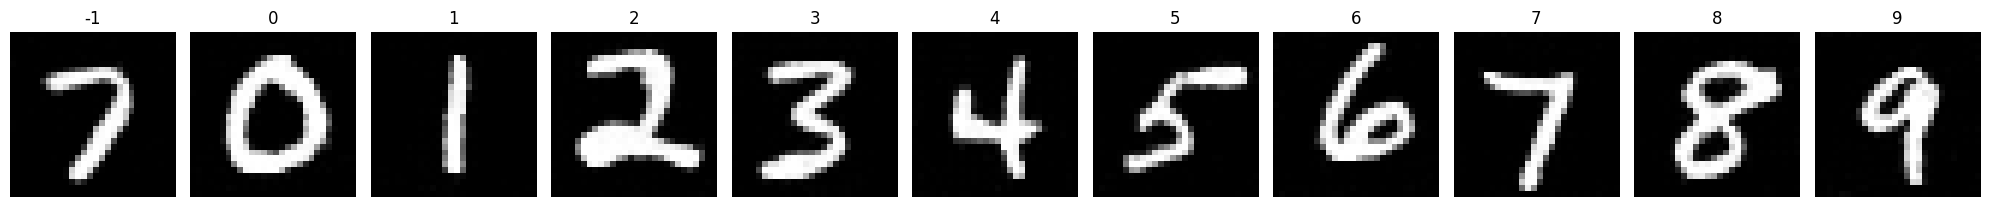

Epoch 76/100
468/468 [==============================] - 32s 69ms/step - noise_loss: 0.0265 - val_loss: 0.0481 - val_noise_loss: 0.0481 - val_image_loss: 0.2258 - learning_rate: 6.7758e-04


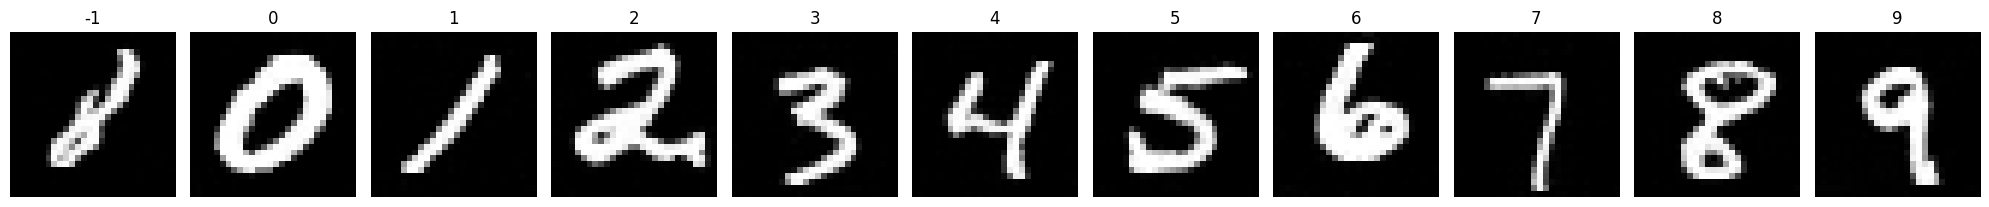

Epoch 77/100
468/468 [==============================] - 32s 67ms/step - noise_loss: 0.0265 - val_loss: 0.0481 - val_noise_loss: 0.0481 - val_image_loss: 0.2247 - learning_rate: 6.2472e-04


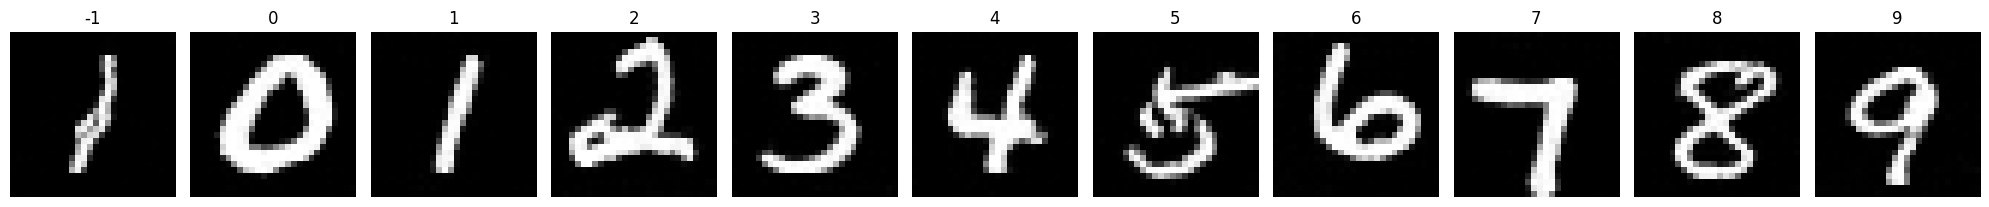

Epoch 78/100
468/468 [==============================] - 32s 68ms/step - noise_loss: 0.0265 - val_loss: 0.0476 - val_noise_loss: 0.0476 - val_image_loss: 0.2275 - learning_rate: 5.7372e-04


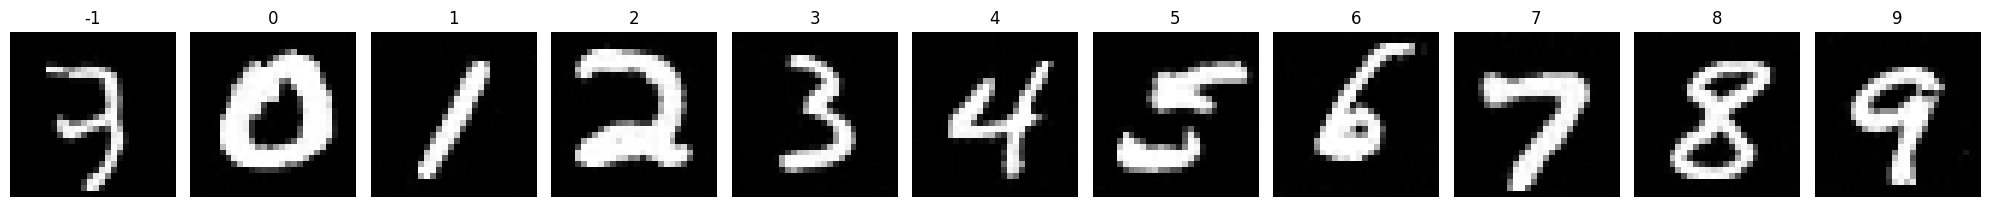

Epoch 79/100
468/468 [==============================] - 32s 69ms/step - noise_loss: 0.0264 - val_loss: 0.0482 - val_noise_loss: 0.0482 - val_image_loss: 0.2258 - learning_rate: 5.2461e-04


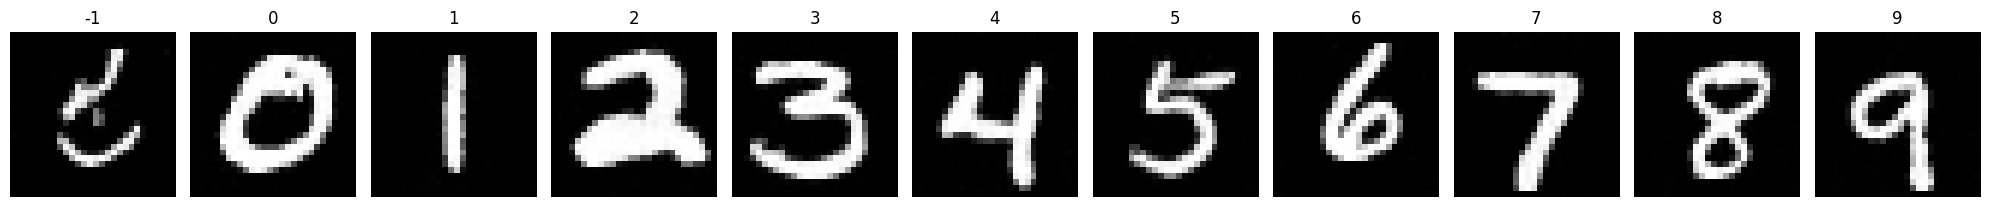

Epoch 80/100
468/468 [==============================] - 32s 68ms/step - noise_loss: 0.0265 - val_loss: 0.0483 - val_noise_loss: 0.0483 - val_image_loss: 0.2201 - learning_rate: 4.7746e-04


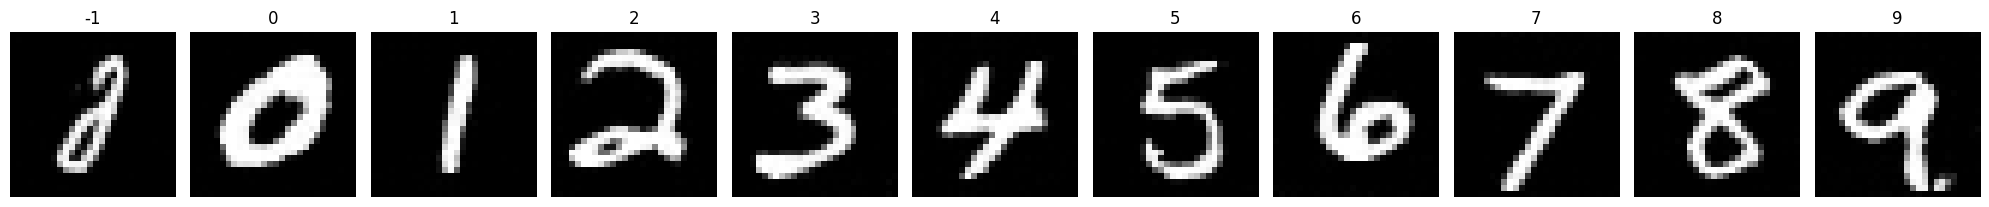

Epoch 81/100
468/468 [==============================] - 34s 71ms/step - noise_loss: 0.0264 - val_loss: 0.0486 - val_noise_loss: 0.0486 - val_image_loss: 0.2262 - learning_rate: 4.3230e-04


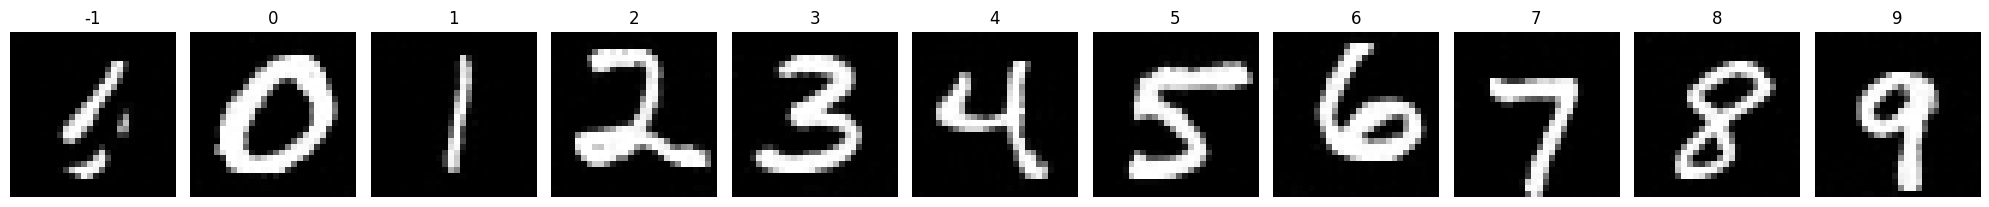

Epoch 82/100
468/468 [==============================] - 33s 71ms/step - noise_loss: 0.0264 - val_loss: 0.0481 - val_noise_loss: 0.0481 - val_image_loss: 0.2206 - learning_rate: 3.8918e-04


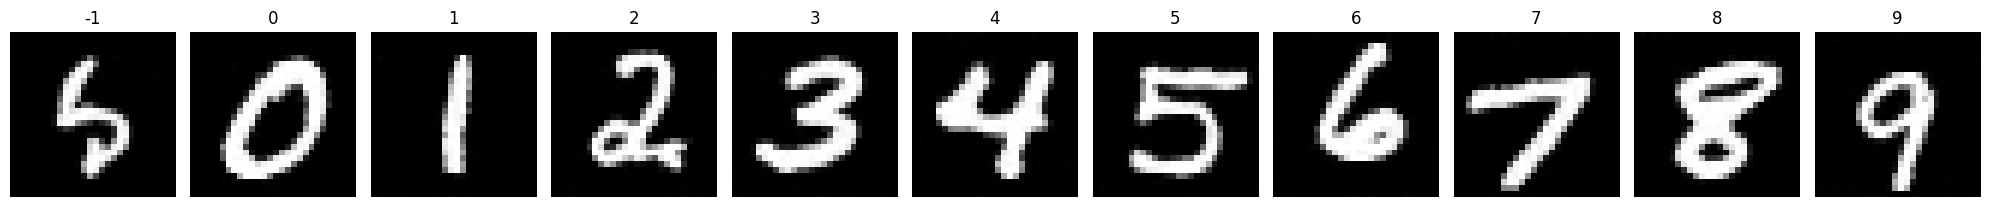

Epoch 83/100
468/468 [==============================] - 33s 70ms/step - noise_loss: 0.0263 - val_loss: 0.0481 - val_noise_loss: 0.0481 - val_image_loss: 0.2301 - learning_rate: 3.4814e-04


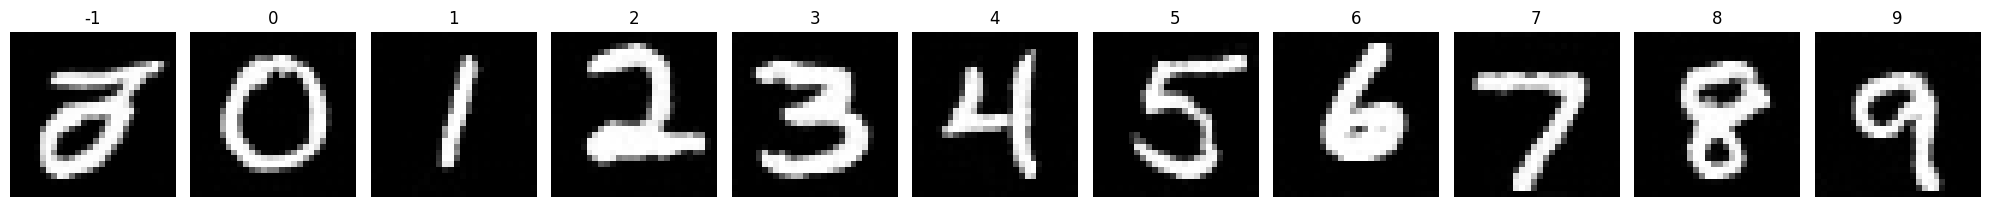

Epoch 84/100
468/468 [==============================] - 33s 70ms/step - noise_loss: 0.0262 - val_loss: 0.0477 - val_noise_loss: 0.0477 - val_image_loss: 0.2293 - learning_rate: 3.0923e-04


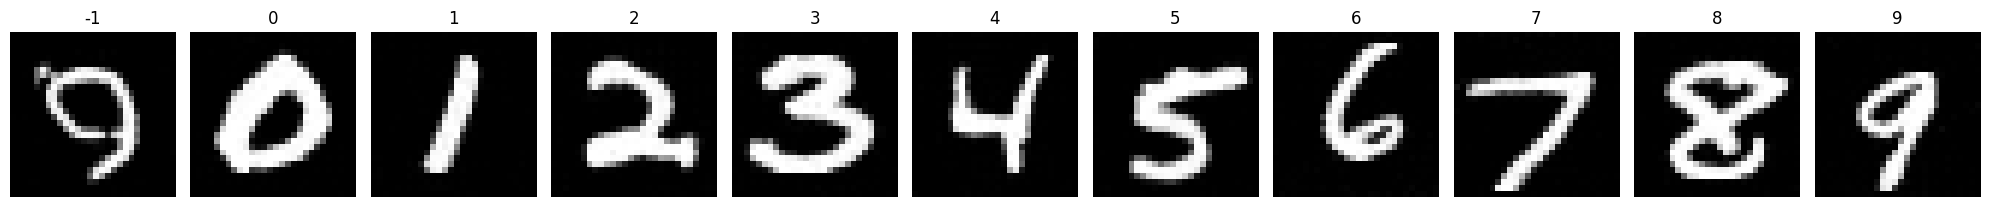

Epoch 85/100
468/468 [==============================] - 33s 70ms/step - noise_loss: 0.0263 - val_loss: 0.0483 - val_noise_loss: 0.0483 - val_image_loss: 0.2296 - learning_rate: 2.7248e-04


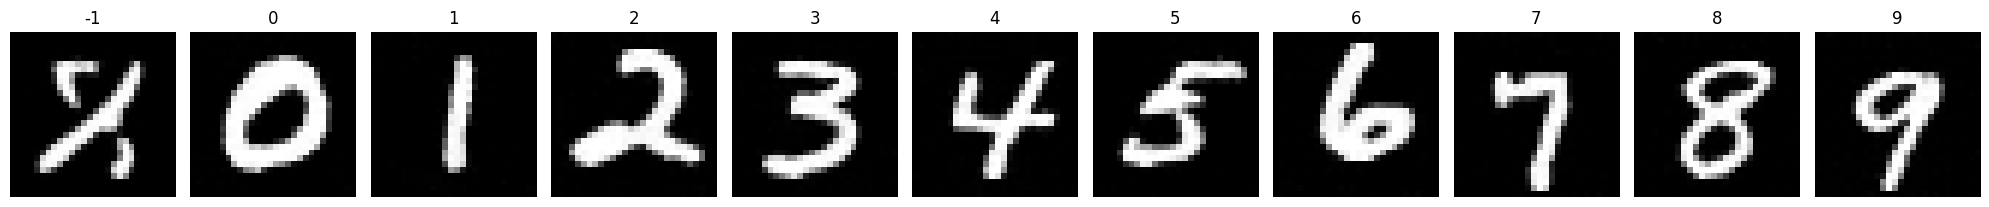

Epoch 86/100
468/468 [==============================] - 33s 71ms/step - noise_loss: 0.0262 - val_loss: 0.0482 - val_noise_loss: 0.0482 - val_image_loss: 0.2226 - learning_rate: 2.3793e-04


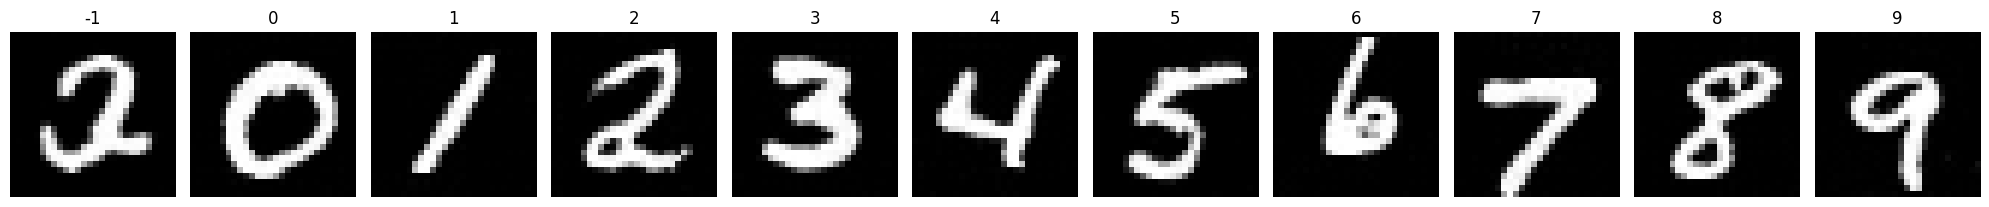

Epoch 87/100
468/468 [==============================] - 33s 71ms/step - noise_loss: 0.0261 - val_loss: 0.0491 - val_noise_loss: 0.0491 - val_image_loss: 0.2254 - learning_rate: 2.0561e-04


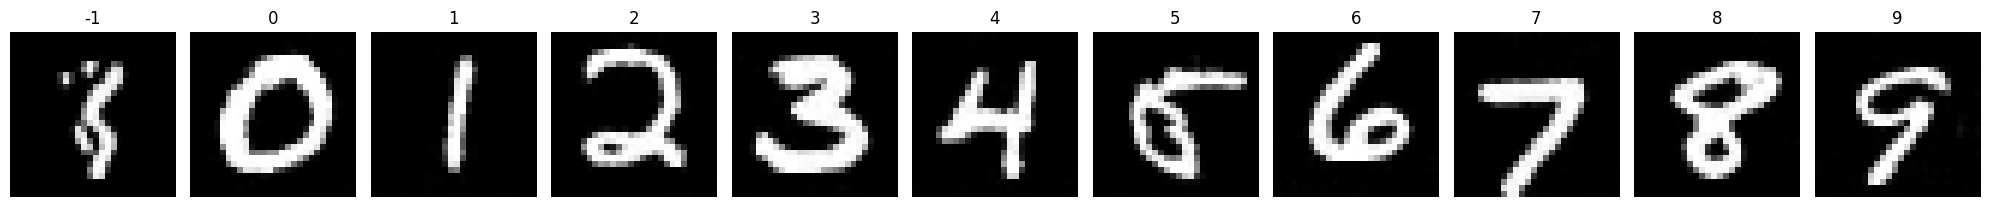

Epoch 88/100
468/468 [==============================] - 36s 77ms/step - noise_loss: 0.0264 - val_loss: 0.0483 - val_noise_loss: 0.0483 - val_image_loss: 0.2274 - learning_rate: 1.7556e-04


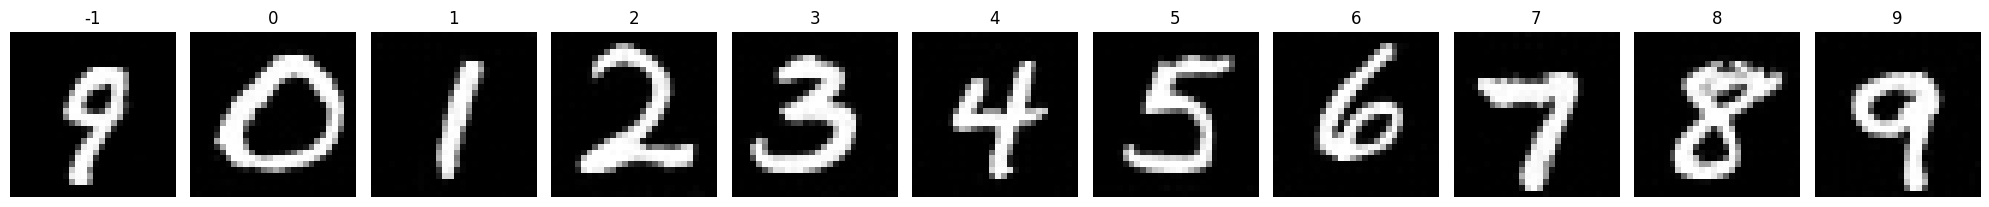

Epoch 89/100
468/468 [==============================] - 37s 80ms/step - noise_loss: 0.0262 - val_loss: 0.0488 - val_noise_loss: 0.0488 - val_image_loss: 0.2259 - learning_rate: 1.4780e-04


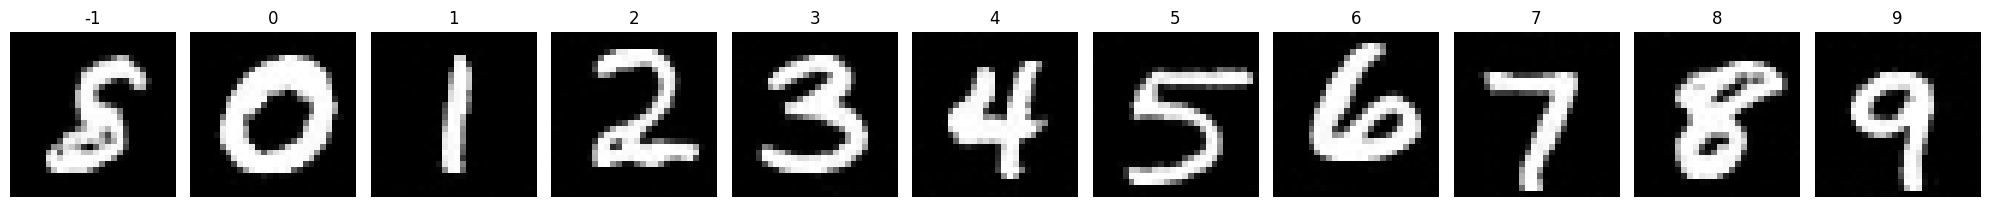

Epoch 90/100
468/468 [==============================] - 37s 78ms/step - noise_loss: 0.0261 - val_loss: 0.0483 - val_noise_loss: 0.0483 - val_image_loss: 0.2305 - learning_rate: 1.2236e-04


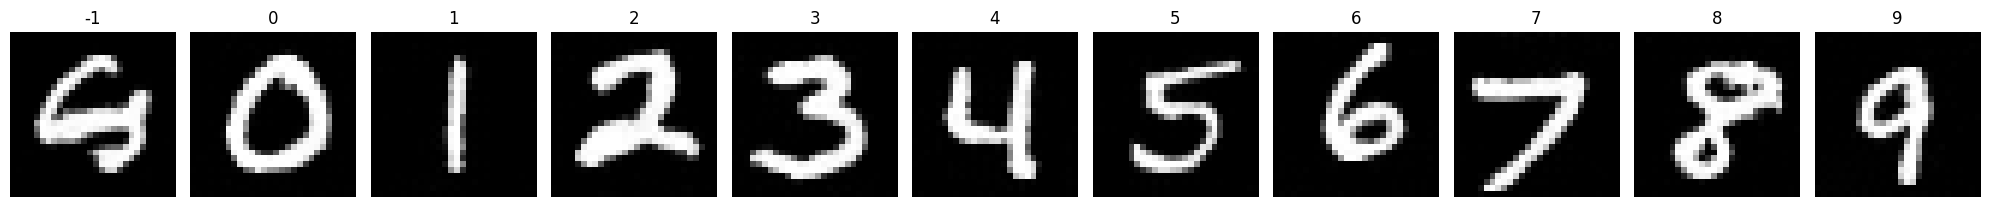

Epoch 91/100
468/468 [==============================] - 38s 81ms/step - noise_loss: 0.0261 - val_loss: 0.0487 - val_noise_loss: 0.0487 - val_image_loss: 0.2268 - learning_rate: 9.9266e-05


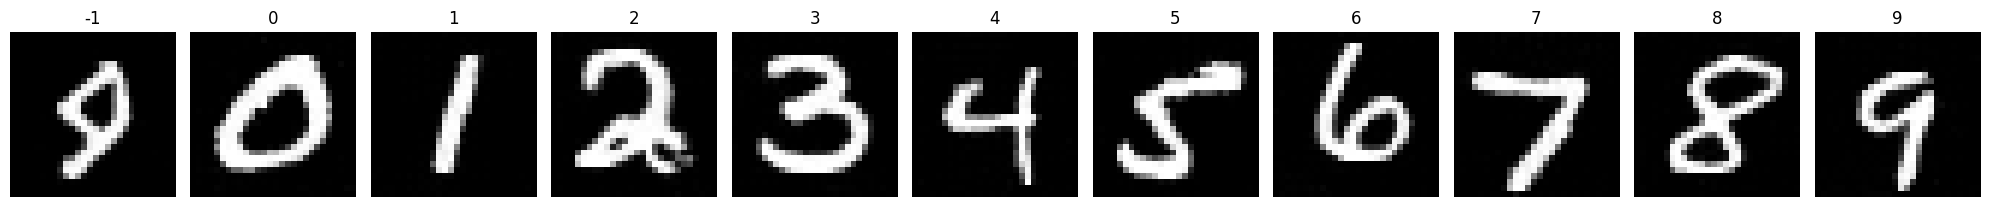

Epoch 92/100
468/468 [==============================] - 37s 78ms/step - noise_loss: 0.0261 - val_loss: 0.0481 - val_noise_loss: 0.0481 - val_image_loss: 0.2249 - learning_rate: 7.8542e-05


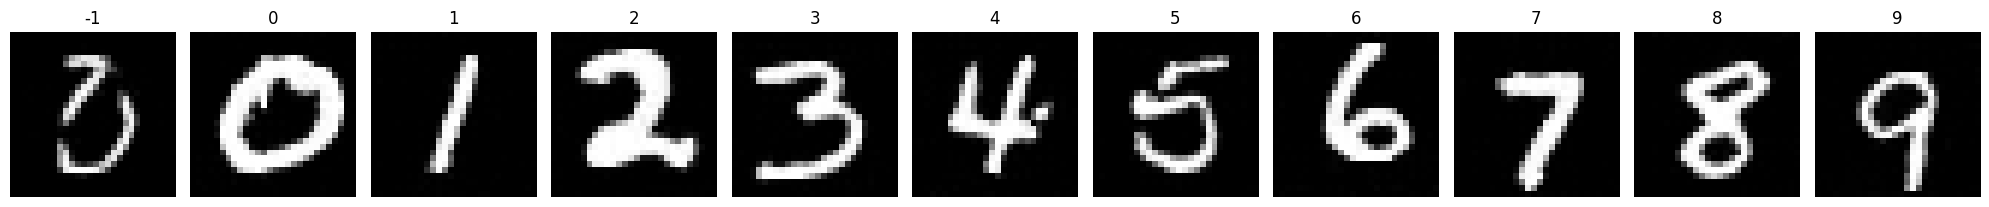

Epoch 93/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0261 - val_loss: 0.0484 - val_noise_loss: 0.0484 - val_image_loss: 0.2243 - learning_rate: 6.0208e-05


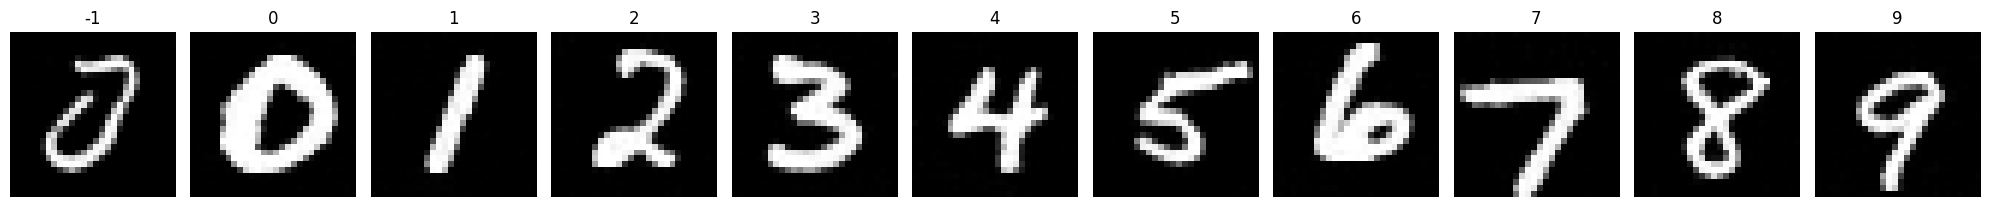

Epoch 94/100
468/468 [==============================] - 37s 78ms/step - noise_loss: 0.0261 - val_loss: 0.0489 - val_noise_loss: 0.0489 - val_image_loss: 0.2234 - learning_rate: 4.4282e-05


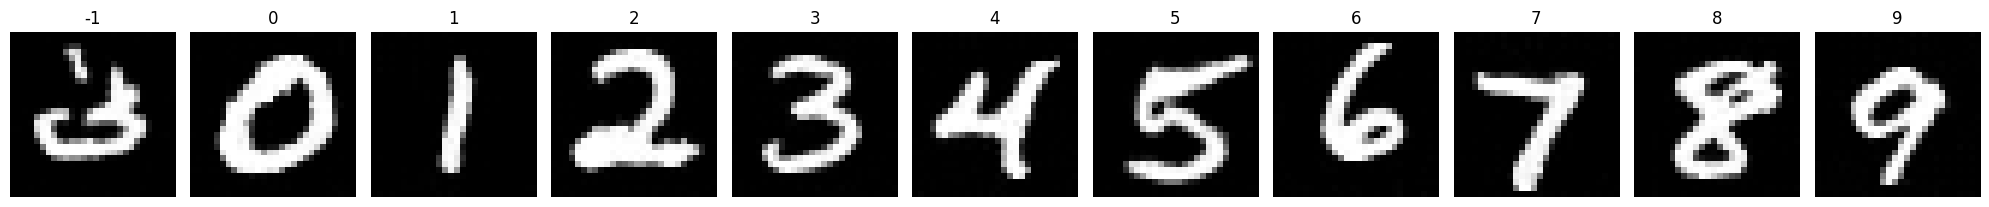

Epoch 95/100
468/468 [==============================] - 37s 80ms/step - noise_loss: 0.0263 - val_loss: 0.0483 - val_noise_loss: 0.0483 - val_image_loss: 0.2257 - learning_rate: 3.0779e-05


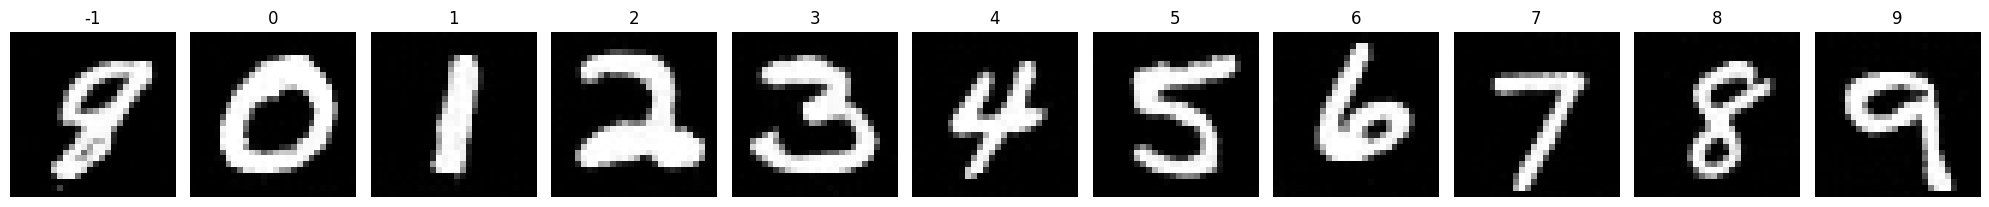

Epoch 96/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0261 - val_loss: 0.0483 - val_noise_loss: 0.0483 - val_image_loss: 0.2338 - learning_rate: 1.9713e-05


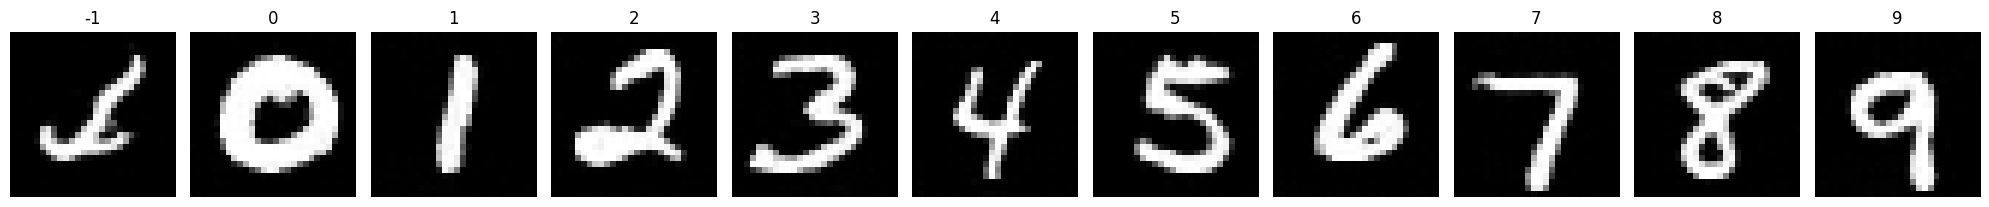

Epoch 97/100
468/468 [==============================] - 37s 80ms/step - noise_loss: 0.0261 - val_loss: 0.0483 - val_noise_loss: 0.0483 - val_image_loss: 0.2339 - learning_rate: 1.1095e-05


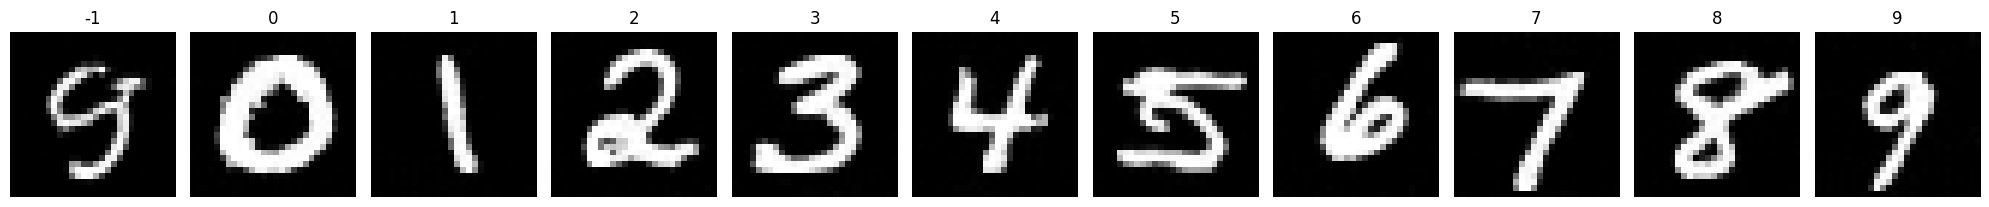

Epoch 98/100
468/468 [==============================] - 37s 79ms/step - noise_loss: 0.0261 - val_loss: 0.0487 - val_noise_loss: 0.0487 - val_image_loss: 0.2346 - learning_rate: 4.9332e-06


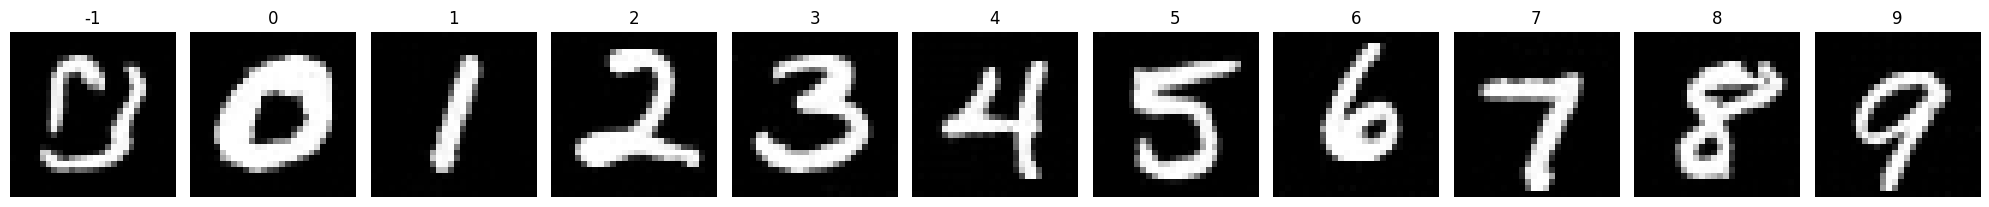

Epoch 99/100
468/468 [==============================] - 38s 80ms/step - noise_loss: 0.0261 - val_loss: 0.0490 - val_noise_loss: 0.0490 - val_image_loss: 0.2245 - learning_rate: 1.2337e-06


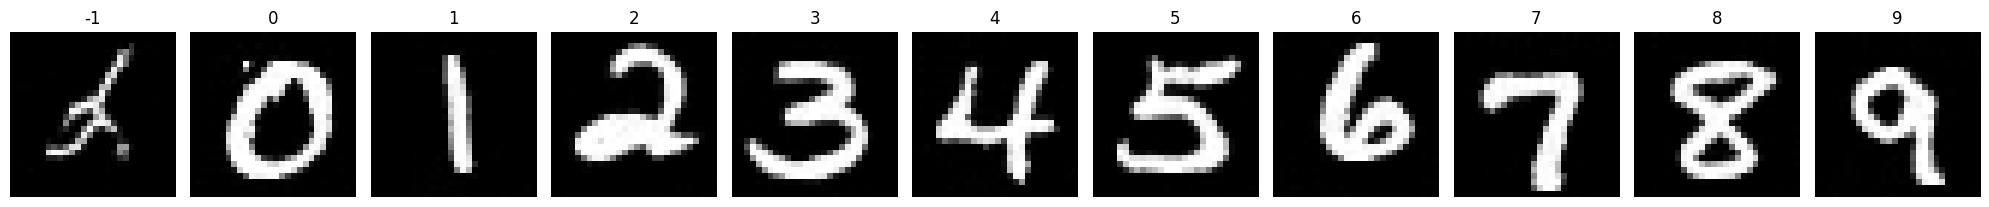

Epoch 100/100
468/468 [==============================] - 37s 78ms/step - noise_loss: 0.0260 - val_loss: 0.0486 - val_noise_loss: 0.0486 - val_image_loss: 0.2272 - learning_rate: 0.0000e+00


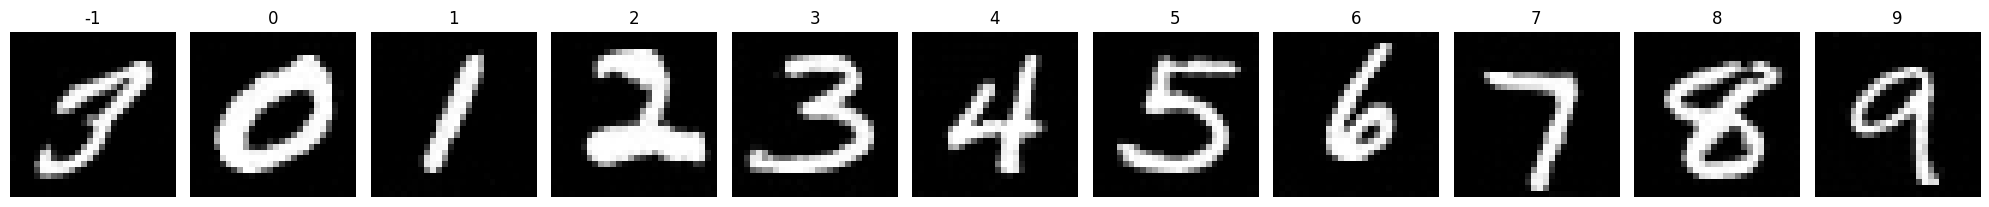

In [10]:
history1 = model.fit_generator(
    x=trainset, 
    epochs=epochs, 
    validation_data=valset, 
    callbacks=callbacks_list
).history

In [11]:
history2 = model.fit_discriminator(
    x=trainset, 
    epochs=epochs, 
    validation_data=valset, 
    callbacks=callbacks_list[:2]
).history

Epoch 1/100
468/468 [==============================] - 42s 81ms/step - classifier_loss: 0.8410 - classifier_accuracy: 0.6884 - val_classifier_loss: 2.1954 - val_classifier_accuracy: 0.2268 - learning_rate: 0.0050
Epoch 2/100
468/468 [==============================] - 37s 79ms/step - classifier_loss: 0.2949 - classifier_accuracy: 0.9042 - val_classifier_loss: 1.7919 - val_classifier_accuracy: 0.3487 - learning_rate: 0.0050
Epoch 3/100
468/468 [==============================] - 37s 79ms/step - classifier_loss: 0.2246 - classifier_accuracy: 0.9278 - val_classifier_loss: 1.1611 - val_classifier_accuracy: 0.5942 - learning_rate: 0.0050
Epoch 4/100
468/468 [==============================] - 37s 80ms/step - classifier_loss: 0.1881 - classifier_accuracy: 0.9386 - val_classifier_loss: 0.5756 - val_classifier_accuracy: 0.8456 - learning_rate: 0.0050
Epoch 5/100
468/468 [==============================] - 37s 79ms/step - classifier_loss: 0.1645 - classifier_accuracy: 0.9473 - val_classifier_loss: 

In [12]:
history = model.merge_result_dicts((history1, history2))

In [29]:
model.save_weights("./models/DiTCLFV2/model.weights.h5")

In [14]:
model.evaluate(x=valset, eval_both=True, network_name="ema")

79/79 [==============================] - 5s 44ms/step - classifier_loss: 0.0323 - classifier_accuracy: 0.9911


{'loss': 0.04847388714551926,
 'noise_loss': 0.04847388714551926,
 'image_loss': 0.22658100724220276,
 'classifier_loss': 0.032307740300893784,
 'classifier_accuracy': 0.991100013256073}

In [15]:
model.evaluate(x=valset, eval_both=True, network_name="raw")

79/79 [==============================] - 5s 44ms/step - classifier_loss: 0.0323 - classifier_accuracy: 0.9910


{'loss': 0.048876311630010605,
 'noise_loss': 0.048876311630010605,
 'image_loss': 0.22403523325920105,
 'classifier_loss': 0.03225356340408325,
 'classifier_accuracy': 0.9909999966621399}

In [16]:
model.evaluate_ensemble_accuracy(
    valset, 
    t_chunk_size=2, 
    max_t=256
)

Step (79/79) --- Ensemble Accuracy: 0.9941


0.9940999746322632

In [17]:
model.evaluate_ensemble_accuracy(
    valset, 
    t_chunk_size=2, 
    max_t=128
)

Step (79/79) --- Ensemble Accuracy: 0.9932


0.9932000041007996

In [18]:
model.evaluate_ensemble_accuracy(
    valset, 
    t_chunk_size=2, 
    max_t=64
)

Step (79/79) --- Ensemble Accuracy: 0.9929


0.992900013923645

In [19]:
model.evaluate_ensemble_accuracy(
    valset, 
    t_chunk_size=2, 
    max_t=32
)

Step (79/79) --- Ensemble Accuracy: 0.9928


0.9927999973297119

In [20]:
model.evaluate_ensemble_accuracy(
    valset, 
    t_chunk_size=2, 
    max_t=16
)

Step (79/79) --- Ensemble Accuracy: 0.9919


0.9919000267982483

In [21]:
model.evaluate_ensemble_accuracy(
    valset, 
    t_chunk_size=2, 
    max_t=8
)

Step (79/79) --- Ensemble Accuracy: 0.9923


0.9922999739646912

In [22]:
model.evaluate_ensemble_accuracy(
    valset, 
    t_chunk_size=2, 
    max_t=4
)

Step (79/79) --- Ensemble Accuracy: 0.9921


0.9921000003814697

Steps: 1000/1000


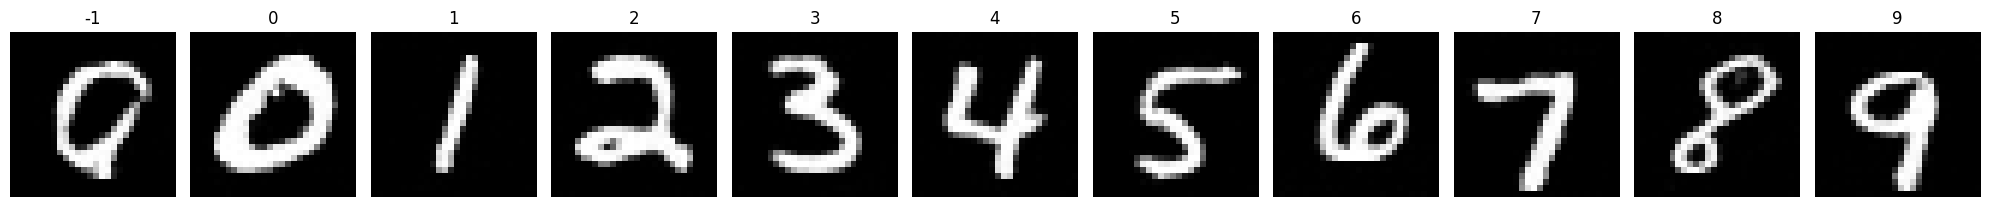

In [23]:
from common.utils import plot_images


imgs = model.sample(add_null_label=True, scale=3., eta=1., steps=1_000, verbose=True)
plot_images(imgs, has_null_label=True)

Steps: 1000/1000


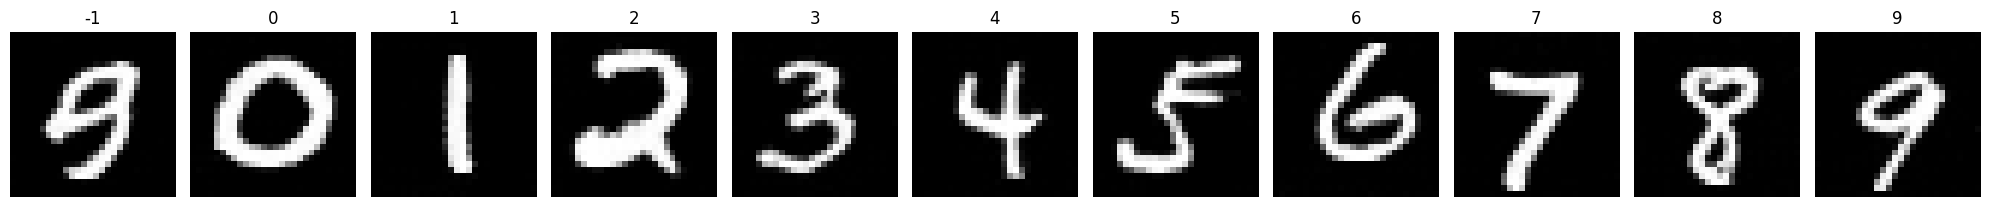

In [24]:
imgs = model.sample(add_null_label=True, scale=3., steps=1_000, verbose=True)
plot_images(imgs, has_null_label=True)

Steps: 50/50


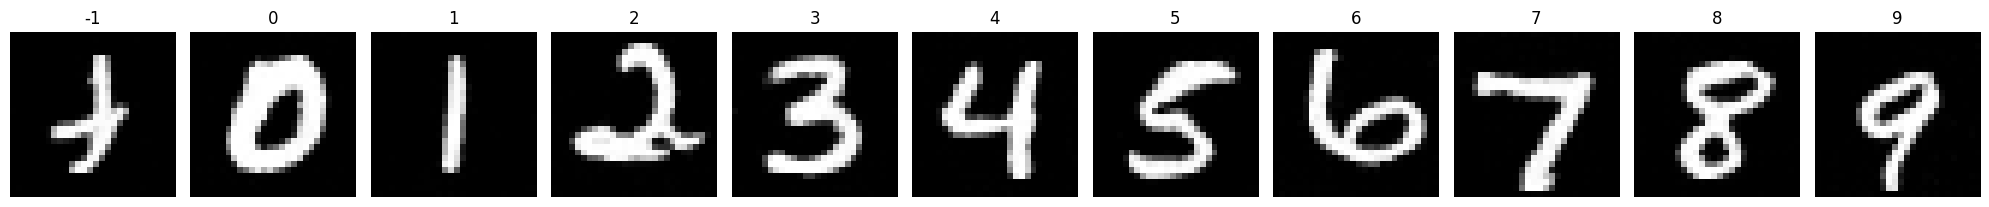

In [25]:
imgs = model.sample(add_null_label=True, scale=3., verbose=True)
plot_images(imgs, has_null_label=True)

Steps: 50/50


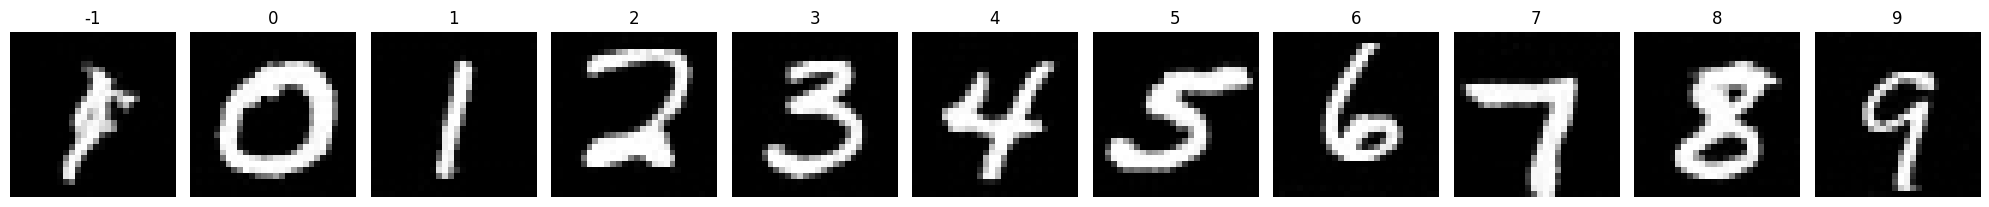

In [26]:
imgs = model.sample(add_null_label=True, scale=4., verbose=True)
plot_images(imgs, has_null_label=True)

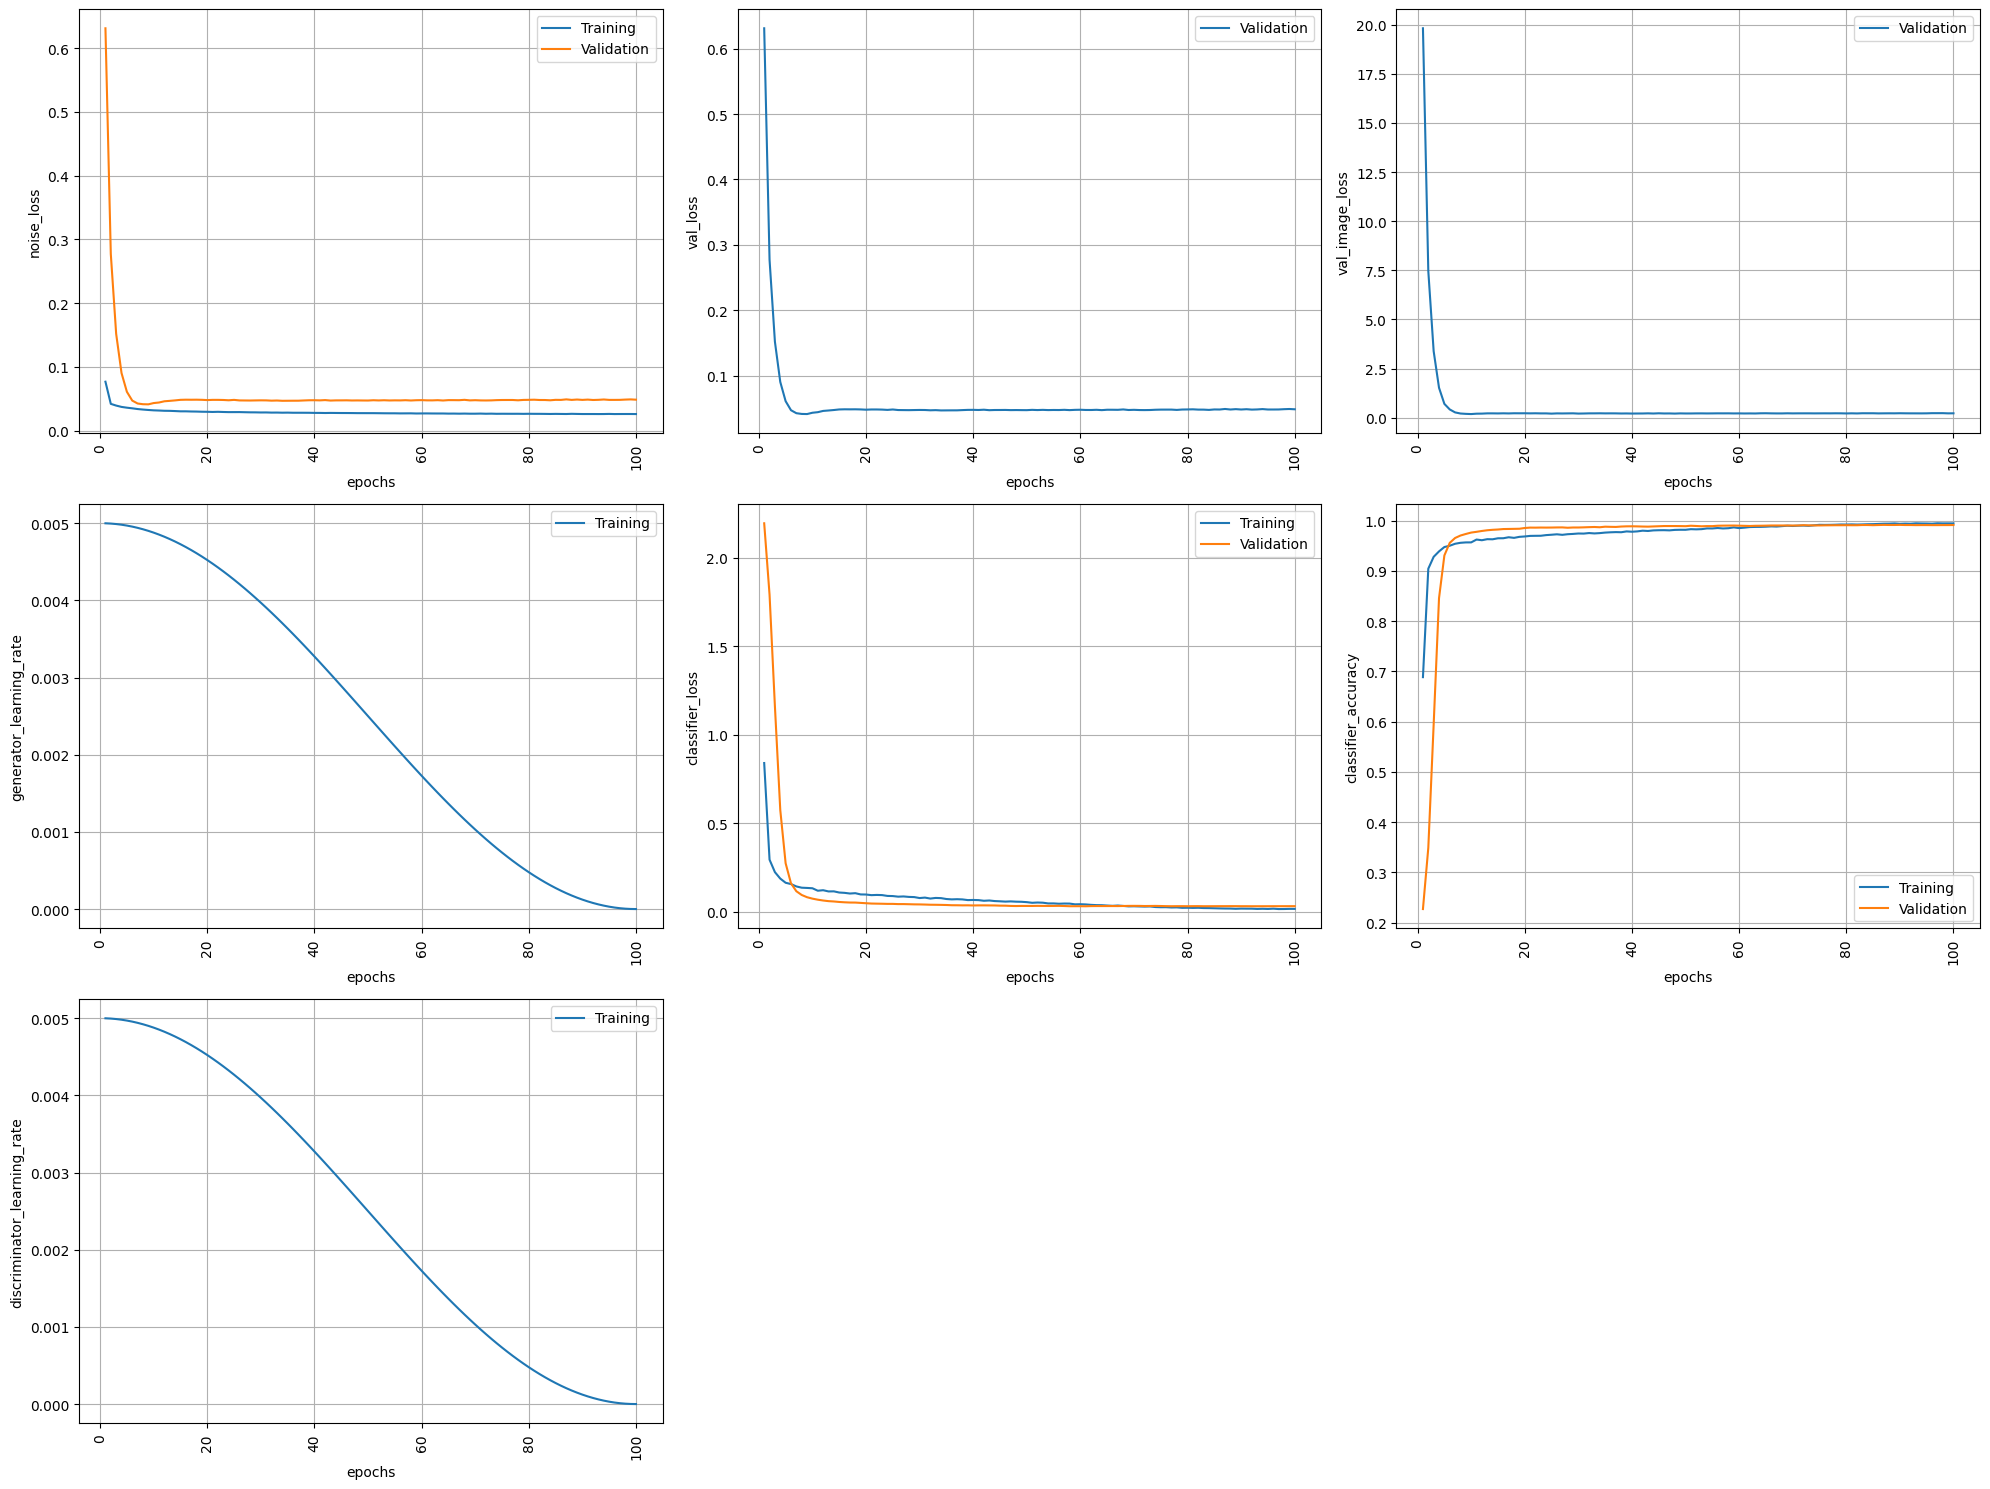

In [27]:
from common.utils import plot_history


plot_history(history)

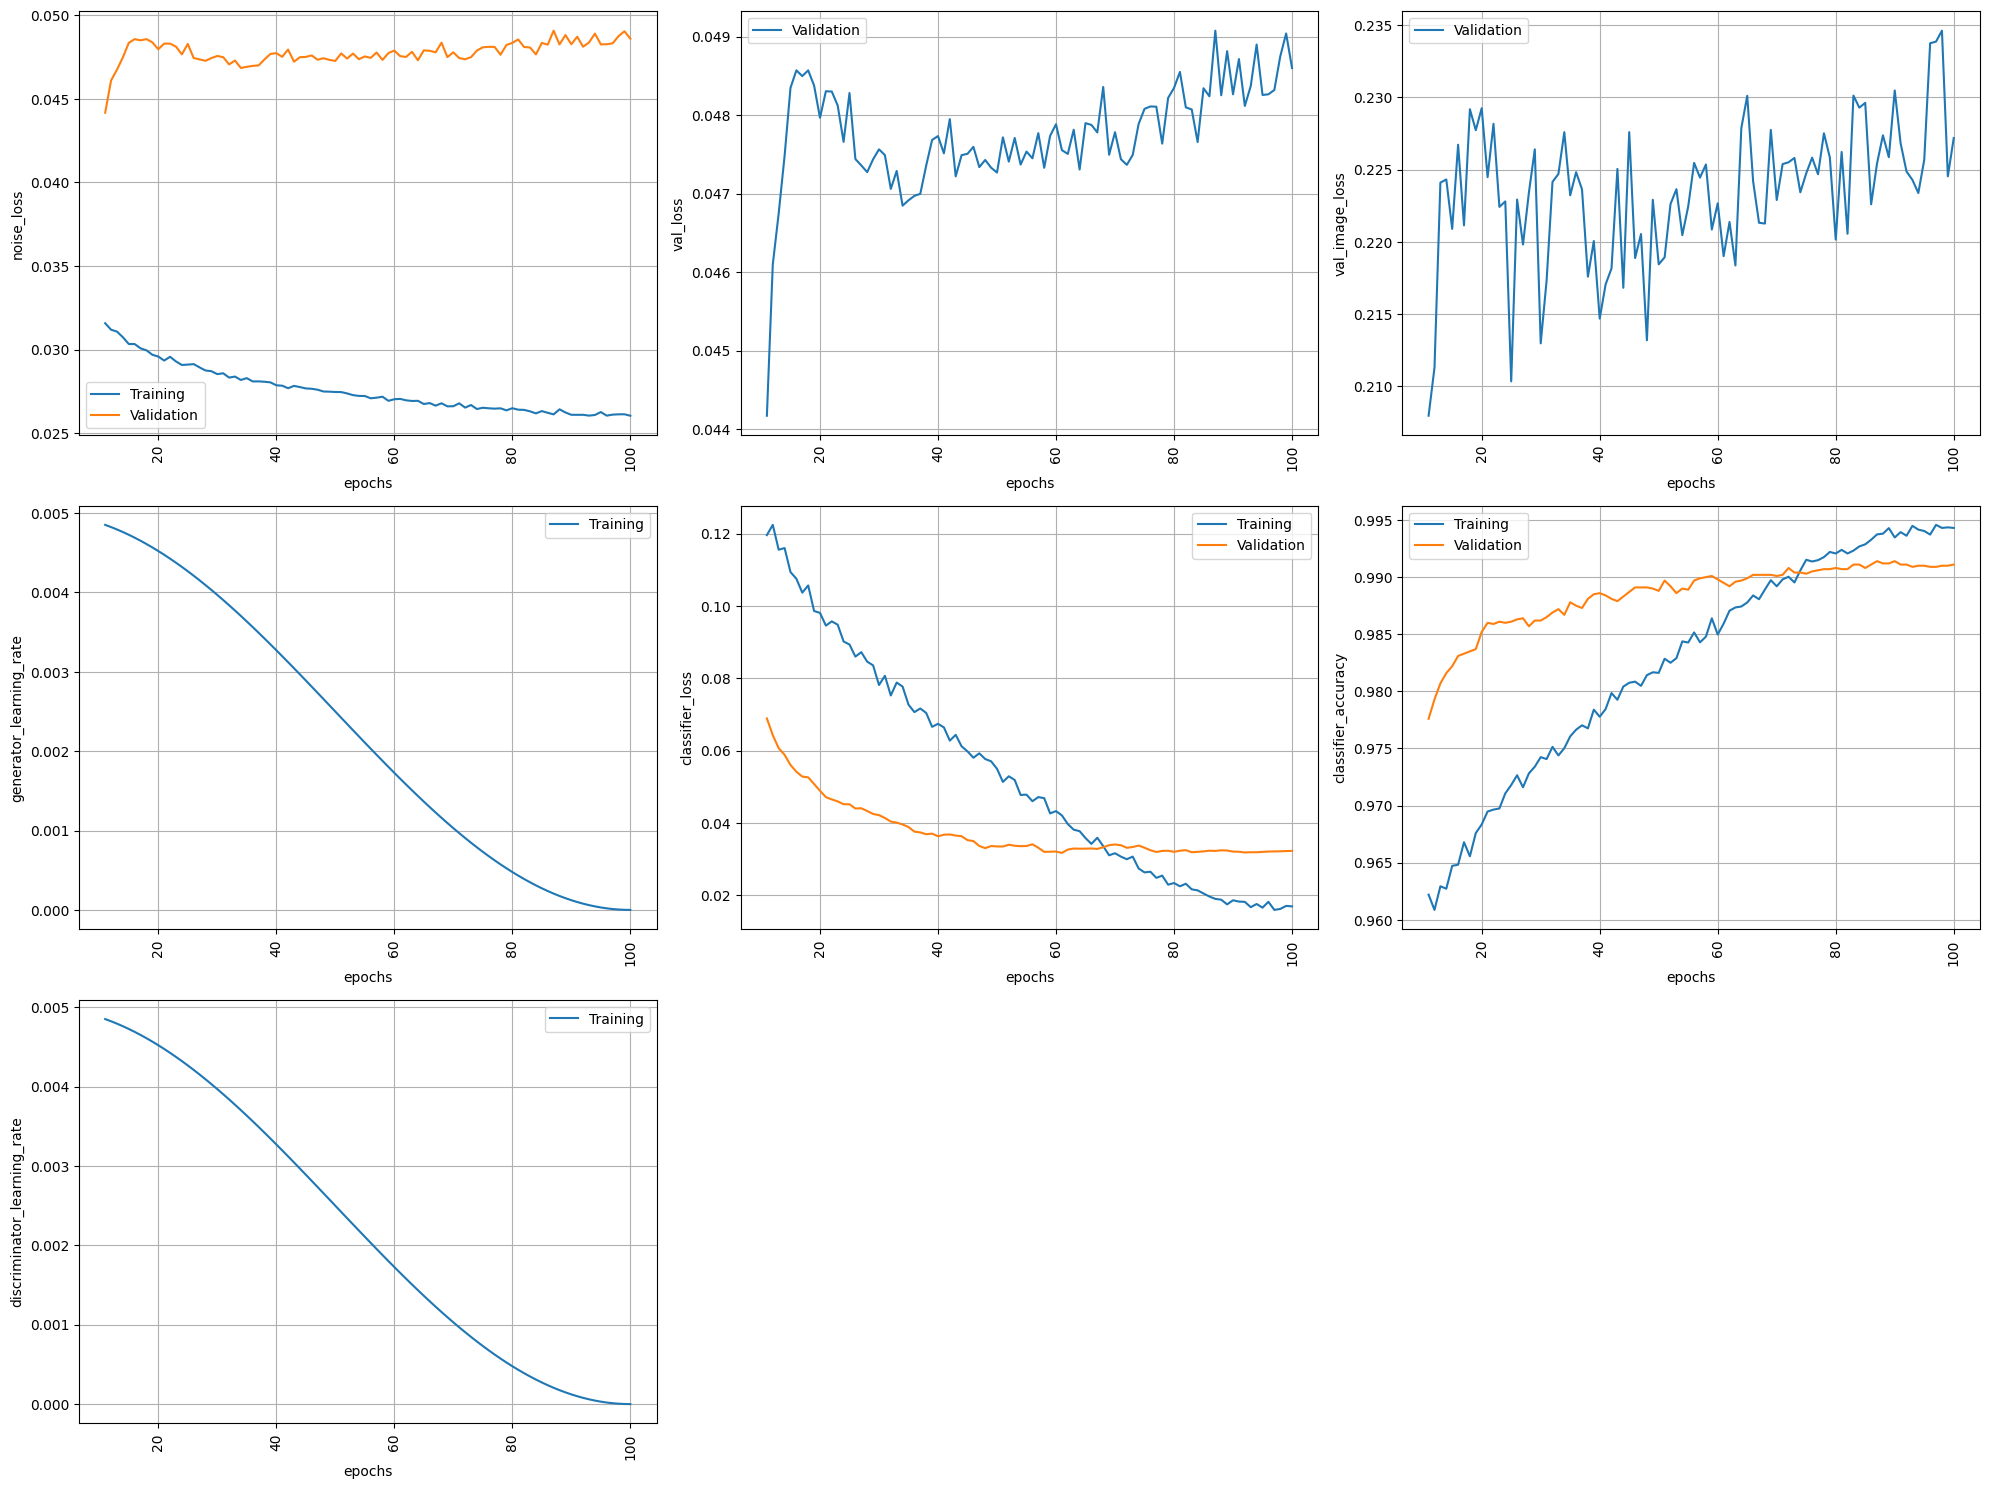

In [28]:
plot_history(history, show_all_x_ticks=False, range_=(10, None))